# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [21]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [22]:
import librosa
import warnings

In [23]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [25]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [26]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [27]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250127__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [28]:
batdetect2_eval = pd.read_csv(bd2_dets_save_dir / '20250127__bd2_eval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_LF = pd.read_csv(bd2_dets_save_dir / '20250127__bd2_LFeval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_HF = pd.read_csv(bd2_dets_save_dir / '20250127__bd2_HFeval_results_per_thresh_and_file.csv', index_col=0)

In [29]:
batdetect2_eval

,SNR_threshold,detection_threshold,num_bd2_detections,num_human_annotations,true_positives,false_positives,false_negatives,true_negatives,precision,recall,input_file_name,site_name
0,0.0,0.01,35448,849,837,34611,14,0,0.023612,0.983549,20220730_053000.WAV,Carp Pond
1,0.0,0.02,35000,849,837,34163,14,0,0.023914,0.983549,20220730_053000.WAV,Carp Pond
2,0.0,0.03,6858,849,827,6031,23,0,0.120589,0.972941,20220730_053000.WAV,Carp Pond
3,0.0,0.04,2726,849,813,1913,36,0,0.298239,0.957597,20220730_053000.WAV,Carp Pond
4,0.0,0.05,1672,849,805,867,44,0,0.481459,0.948174,20220730_053000.WAV,Carp Pond
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,19.0,0.56,1,10,1,0,9,0,1.000000,0.100000,20220829_090000.WAV,Foliage
1196,19.0,0.57,1,10,1,0,9,0,1.000000,0.100000,20220829_090000.WAV,Foliage
1197,19.0,0.58,1,10,1,0,9,0,1.000000,0.100000,20220829_090000.WAV,Foliage
1198,19.0,0.59,0,10,0,0,10,0,NaN,0.000000,20220829_090000.WAV,Foliage


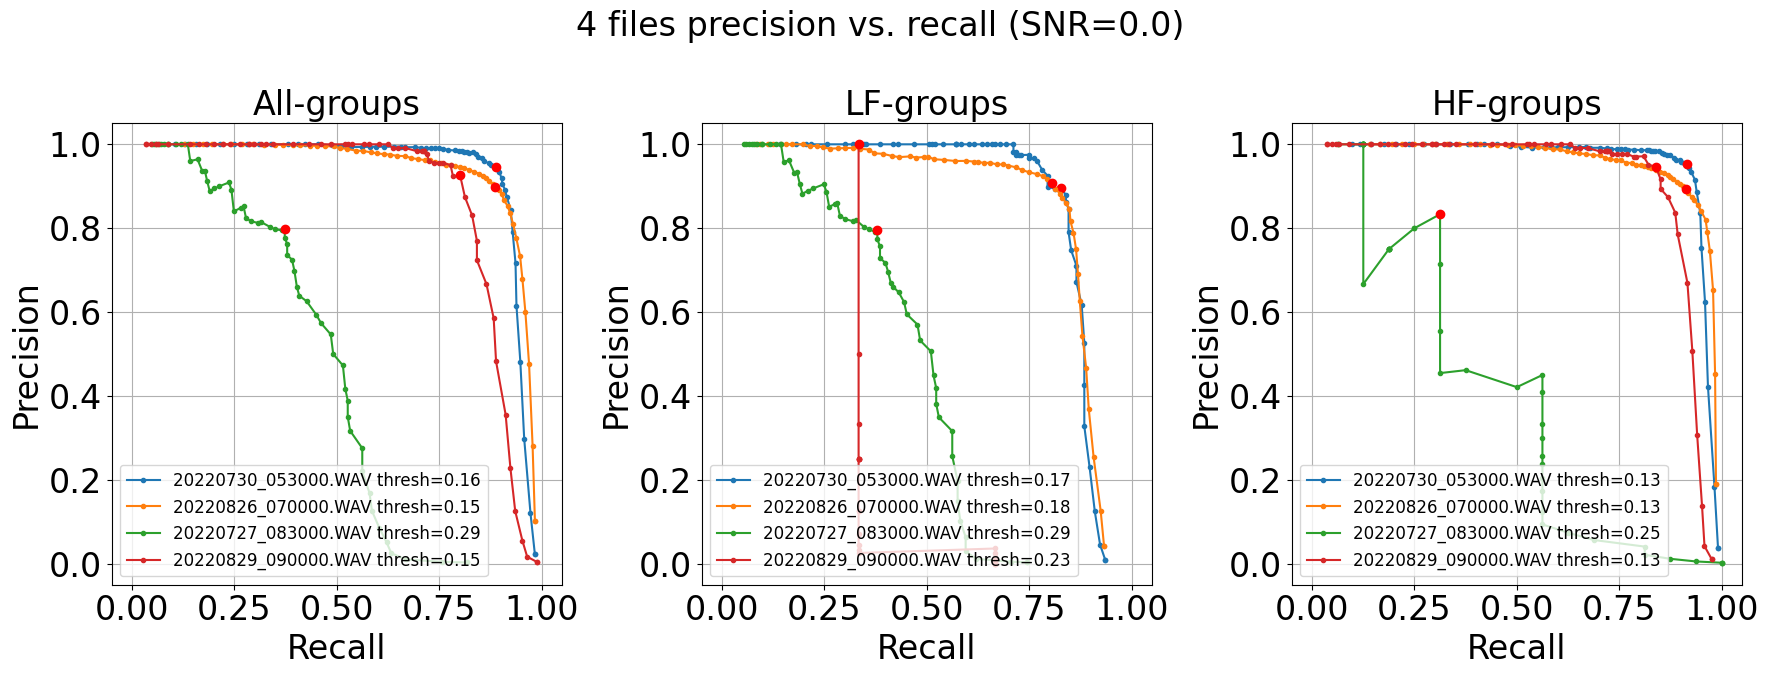

In [30]:
fig, (ax1, ax2, ax3), = plt.subplots(1, 3, figsize=(18,7))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'4 files precision vs. recall (SNR=0.0)')
ax1.set_title(f'All-groups')
for file in batdetect2_eval['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval[batdetect2_eval['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax1.plot(file_recalls_SNR, file_precisions_SNR, marker='.',
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}')
    ax1.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', zorder=2)
ax1.grid(which='both')
ax1.set_xlim(-0.05,1.05)
ax1.set_ylim(-0.05,1.05)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.legend(loc='lower left', fontsize=12)

ax2.set_title(f'LF-groups')
for file in batdetect2_eval_LF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_LF[batdetect2_eval_LF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax2.plot(file_recalls_SNR, file_precisions_SNR, marker='.',
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}')
    ax2.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', zorder=2)
ax2.grid(which='both')
ax2.set_xlim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left', fontsize=12)

ax3.set_title(f'HF-groups')
for file in batdetect2_eval_HF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_HF[batdetect2_eval_HF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax3.plot(file_recalls_SNR, file_precisions_SNR, marker='.', 
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}')
    ax3.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', zorder=2)
ax3.grid(which='both')
ax3.set_xlim(-0.05,1.05)
ax3.set_ylim(-0.05,1.05)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(loc='lower left', fontsize=12)

fig.tight_layout()
plt.show()

In [31]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    precision = true_positives / denom_precision
    recall = true_positives / denom_recall
    
    return precision, recall

In [32]:
all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==4.0].groupby('detection_threshold')
all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
all_files_metrics_summed_by_det_thresh['precision'] = precision
all_files_metrics_summed_by_det_thresh['recall'] = recall

In [37]:
import matplotlib.cm as cm
increment = 1.0
snr_thresholds = np.arange(0, 20, increment)

# Get a colormap and normalize function for the colors
HF_colormap = cm.Reds
LF_colormap = cm.Blues
colormap = cm.Greys
norm = plt.Normalize(vmin=min(snr_thresholds), vmax=max(snr_thresholds))

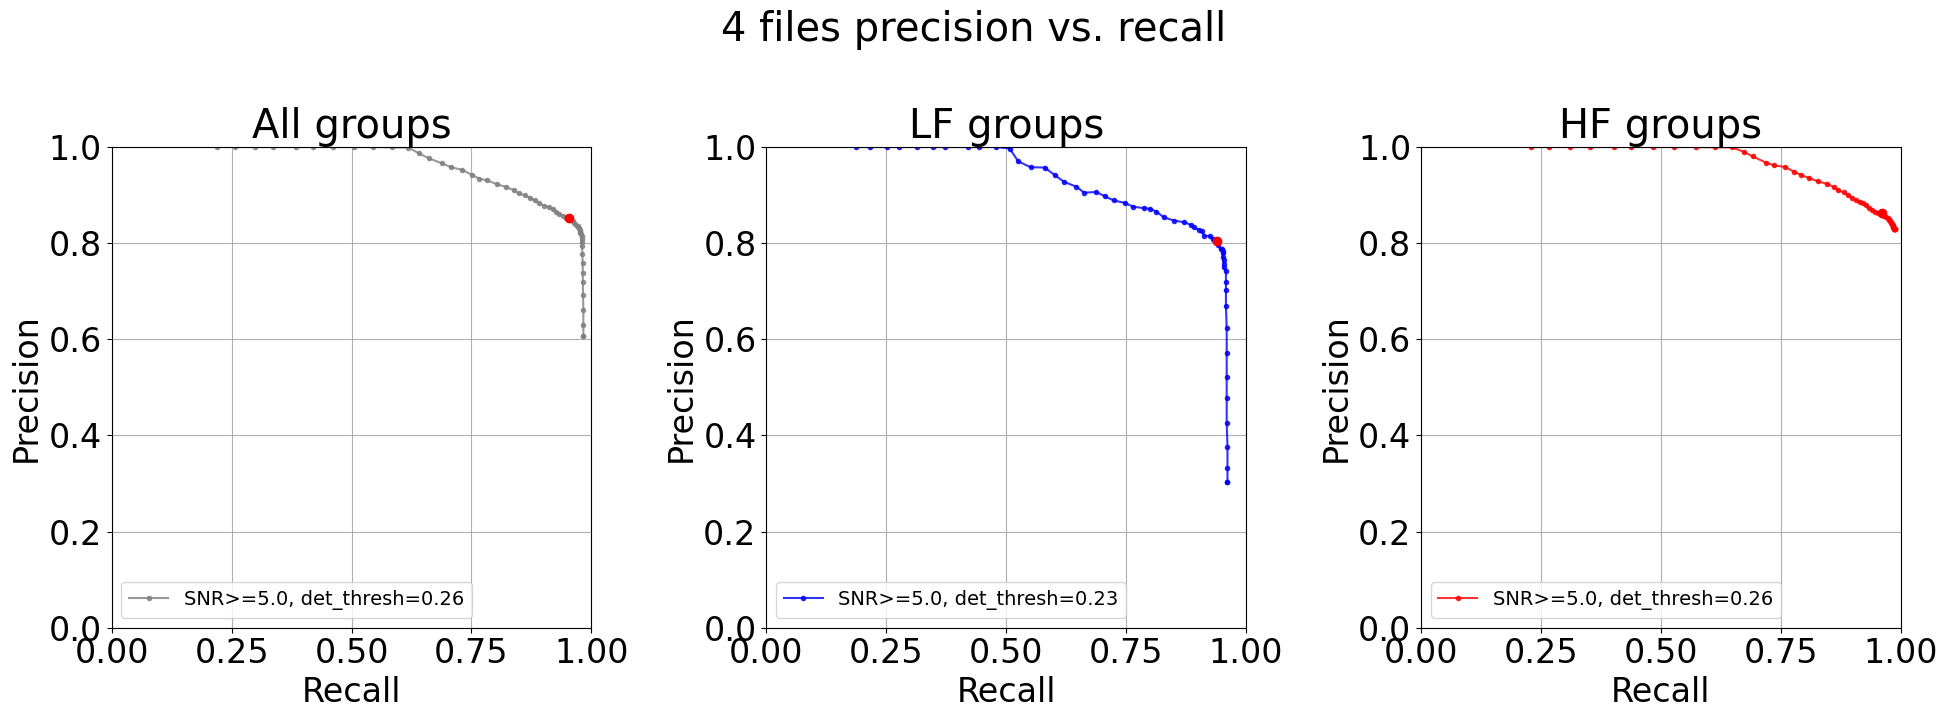

In [38]:
fig, ax_all, = plt.subplots(1, 3, figsize=(20,7.5))
ax_flatten = ax_all.flatten()
SNR_threshold = 5.0

plt.rcParams.update({'font.size':24})
fig.suptitle(f'4 files precision vs. recall')
ax = ax_flatten[0]
ax.set_title(f'All groups')
all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                        all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                        all_files_metrics_summed_by_det_thresh['false_negatives'])

thresholds = all_files_metrics_summed_by_det_thresh.index
quality_ind = (precision*recall).argmax()

ax.plot(recall, precision, marker='.', alpha=0.8, color='grey',
        label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[quality_ind], 3)}')
ax.scatter(recall.iloc[quality_ind], precision.iloc[quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.0,1.0)
ax.set_ylim(0.0,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

ax = ax_flatten[1]
ax.set_title(f'LF groups')
lf_all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
lf_all_files_metrics_summed_by_det_thresh = lf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
LF_precision, LF_recall = get_precision_and_recall_from_metrics(lf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                        lf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                        lf_all_files_metrics_summed_by_det_thresh['false_negatives'])
thresholds = lf_all_files_metrics_summed_by_det_thresh.index
LF_quality_ind = (LF_precision*LF_recall).argmax()

ax.plot(LF_recall, LF_precision, marker='.', alpha=0.8, color='blue',
        label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[LF_quality_ind], 3)}')
ax.scatter(LF_recall.iloc[LF_quality_ind], LF_precision.iloc[LF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.0,1.0)
ax.set_ylim(0.0,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

ax = ax_flatten[2]
ax.set_title(f'HF groups')
hf_all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
hf_all_files_metrics_summed_by_det_thresh = hf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
HF_precision, HF_recall = get_precision_and_recall_from_metrics(hf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                        hf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                        hf_all_files_metrics_summed_by_det_thresh['false_negatives'])
thresholds = hf_all_files_metrics_summed_by_det_thresh.index
HF_quality_ind = (HF_precision*HF_recall).argmax()

ax.plot(HF_recall, HF_precision, marker='.', alpha=0.8, color='red',
        label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[HF_quality_ind], 3)}')
ax.scatter(HF_recall.iloc[HF_quality_ind], HF_precision.iloc[HF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.0,1.0)
ax.set_ylim(0.0,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
plt.show()

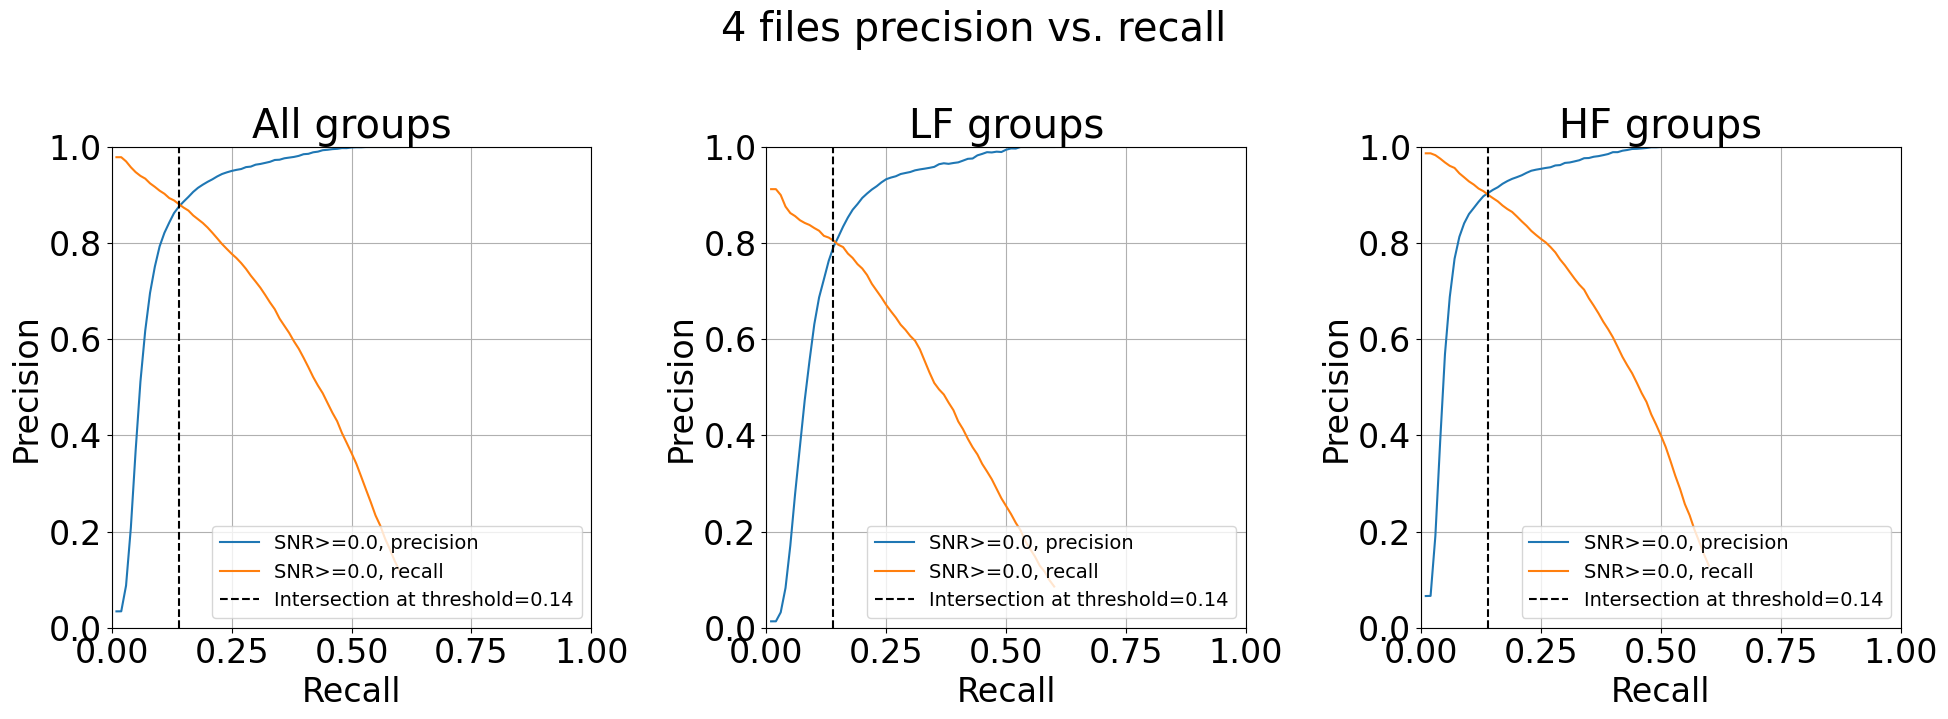

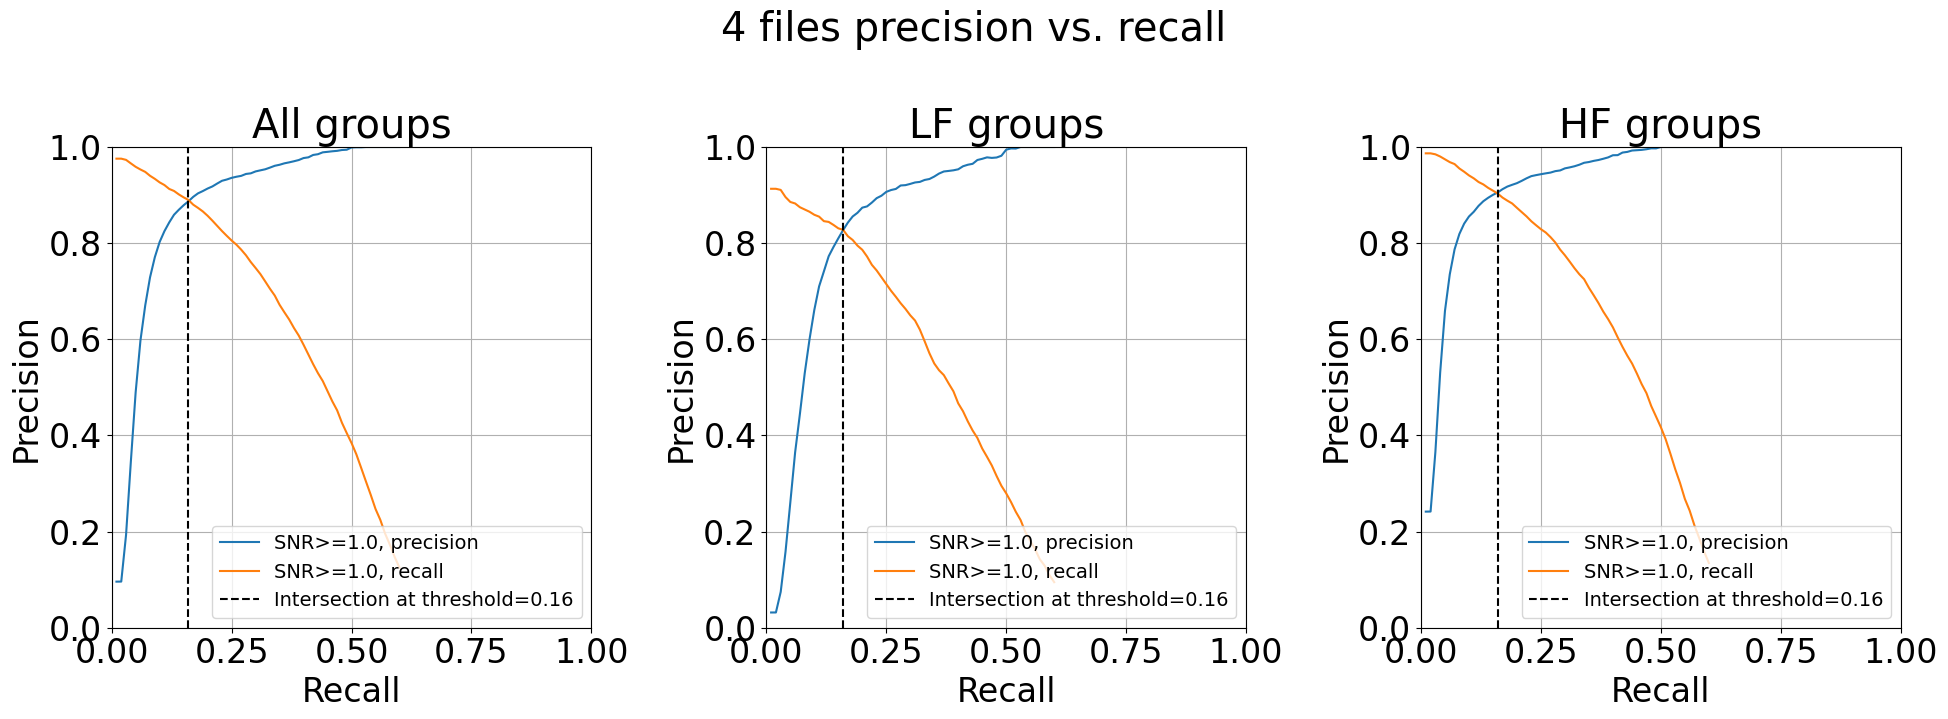

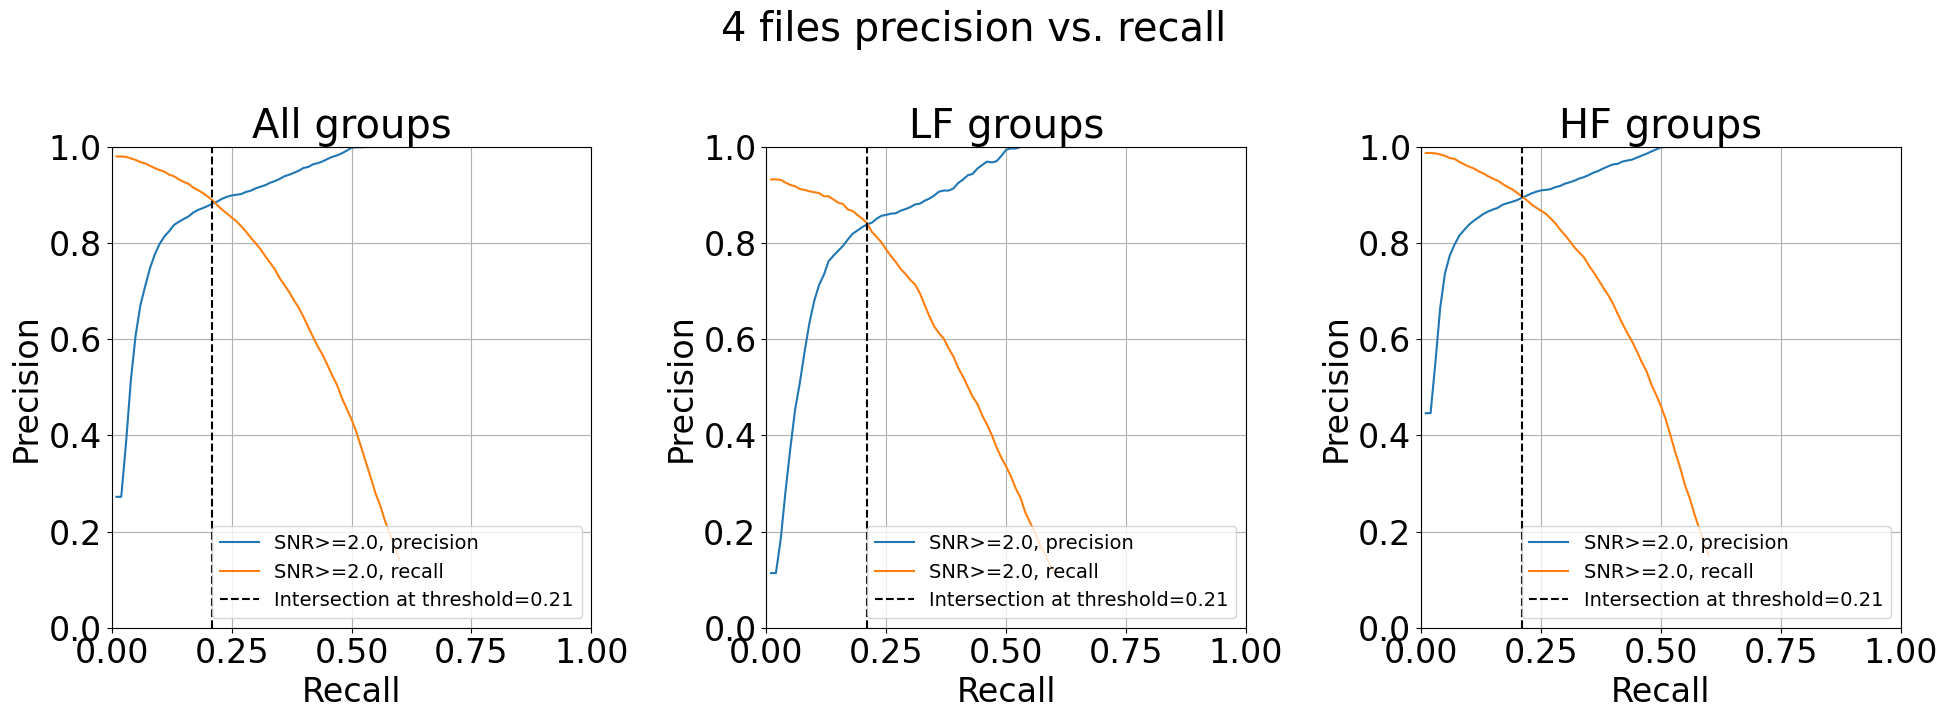

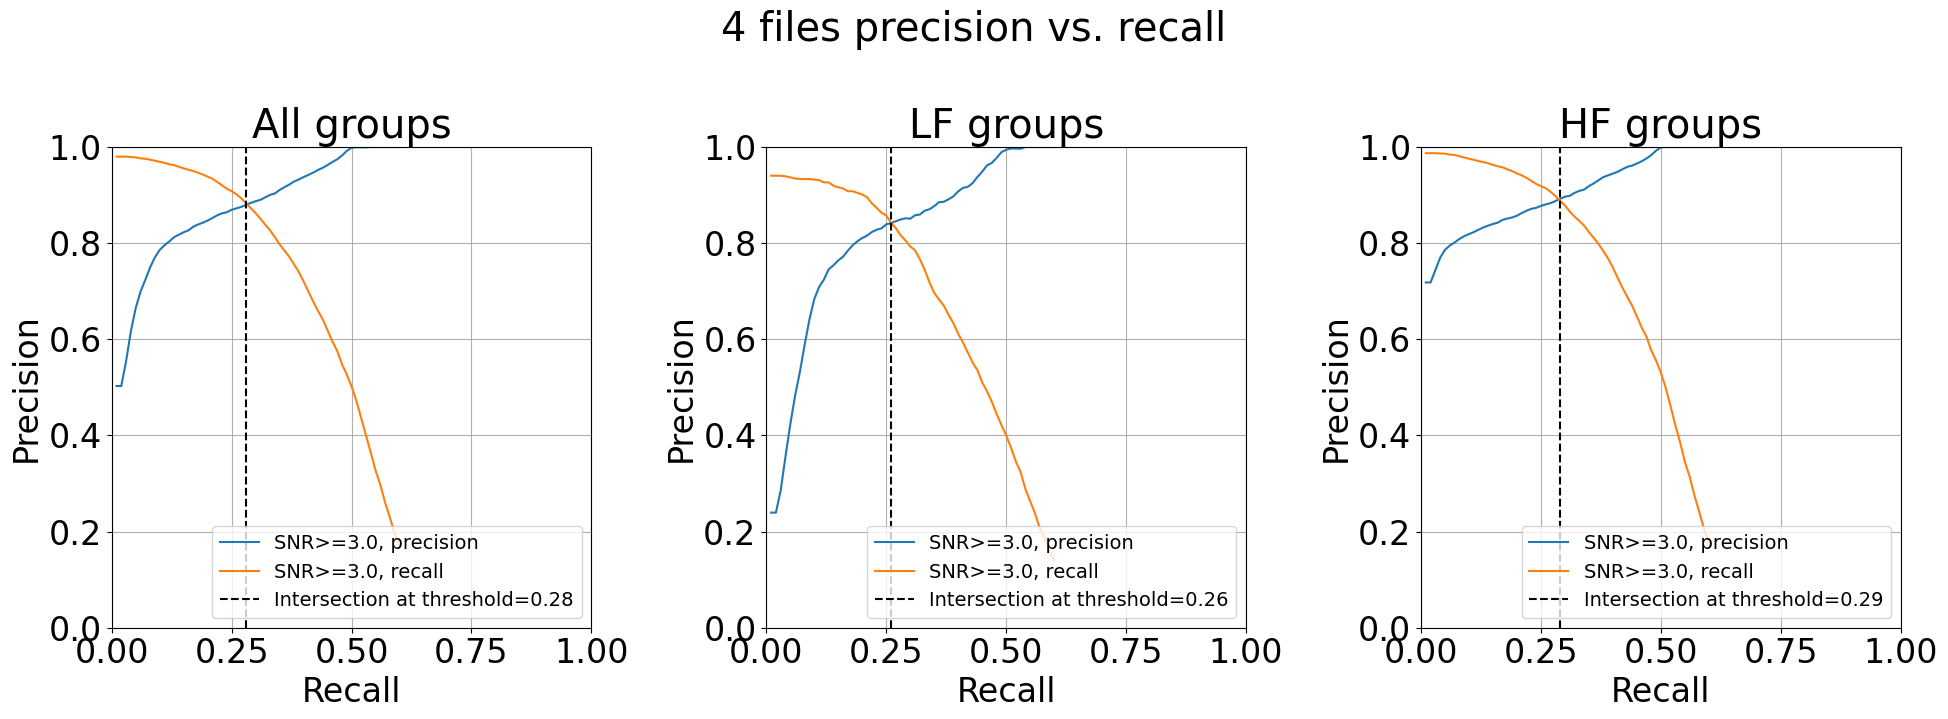

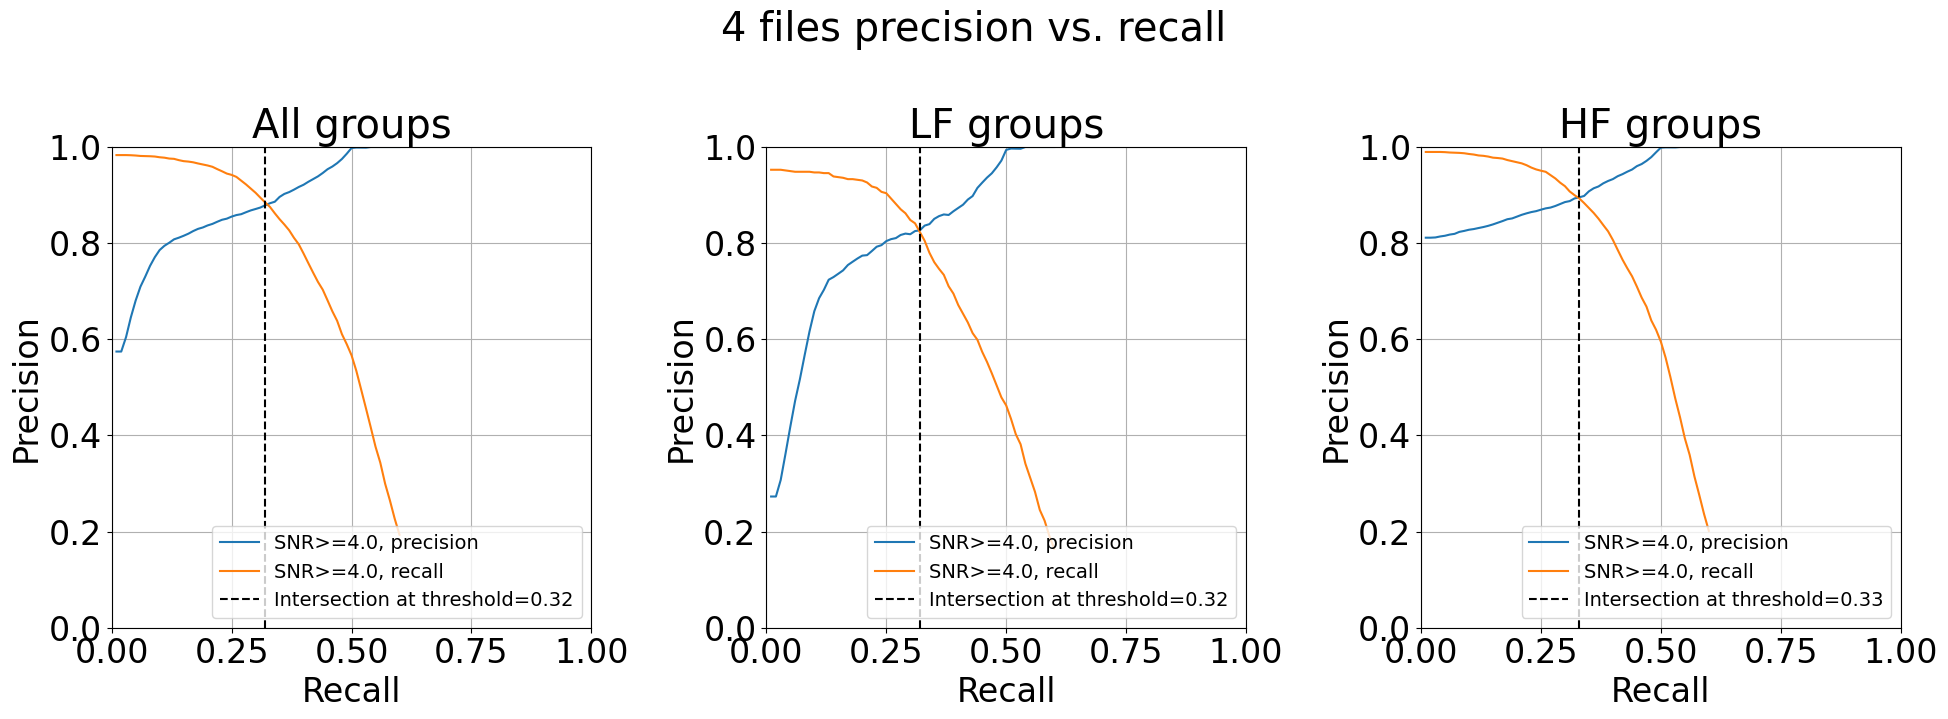

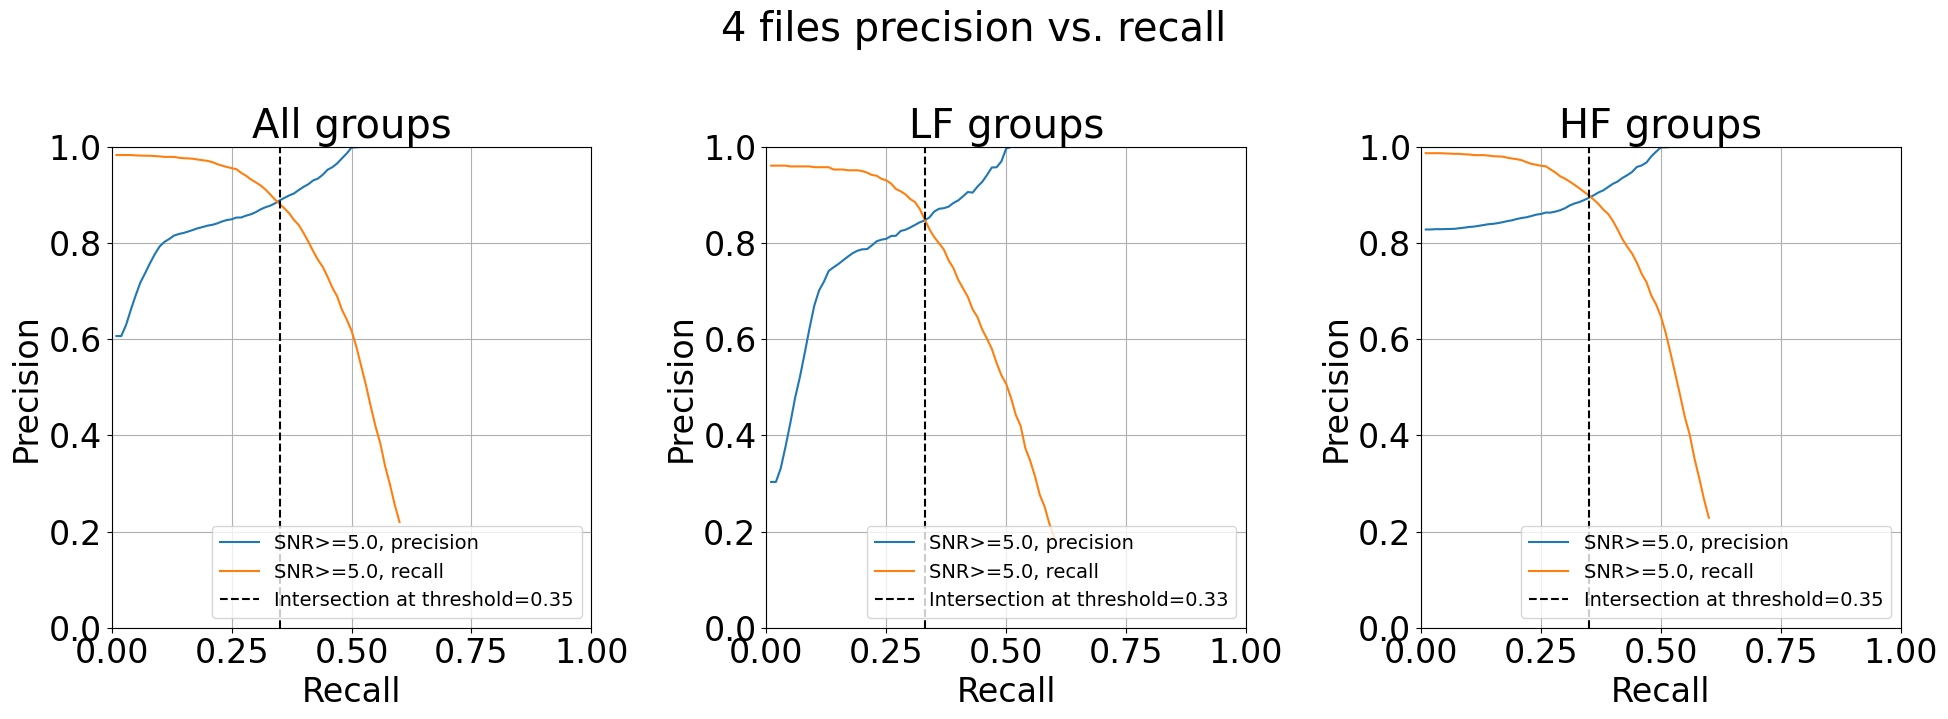

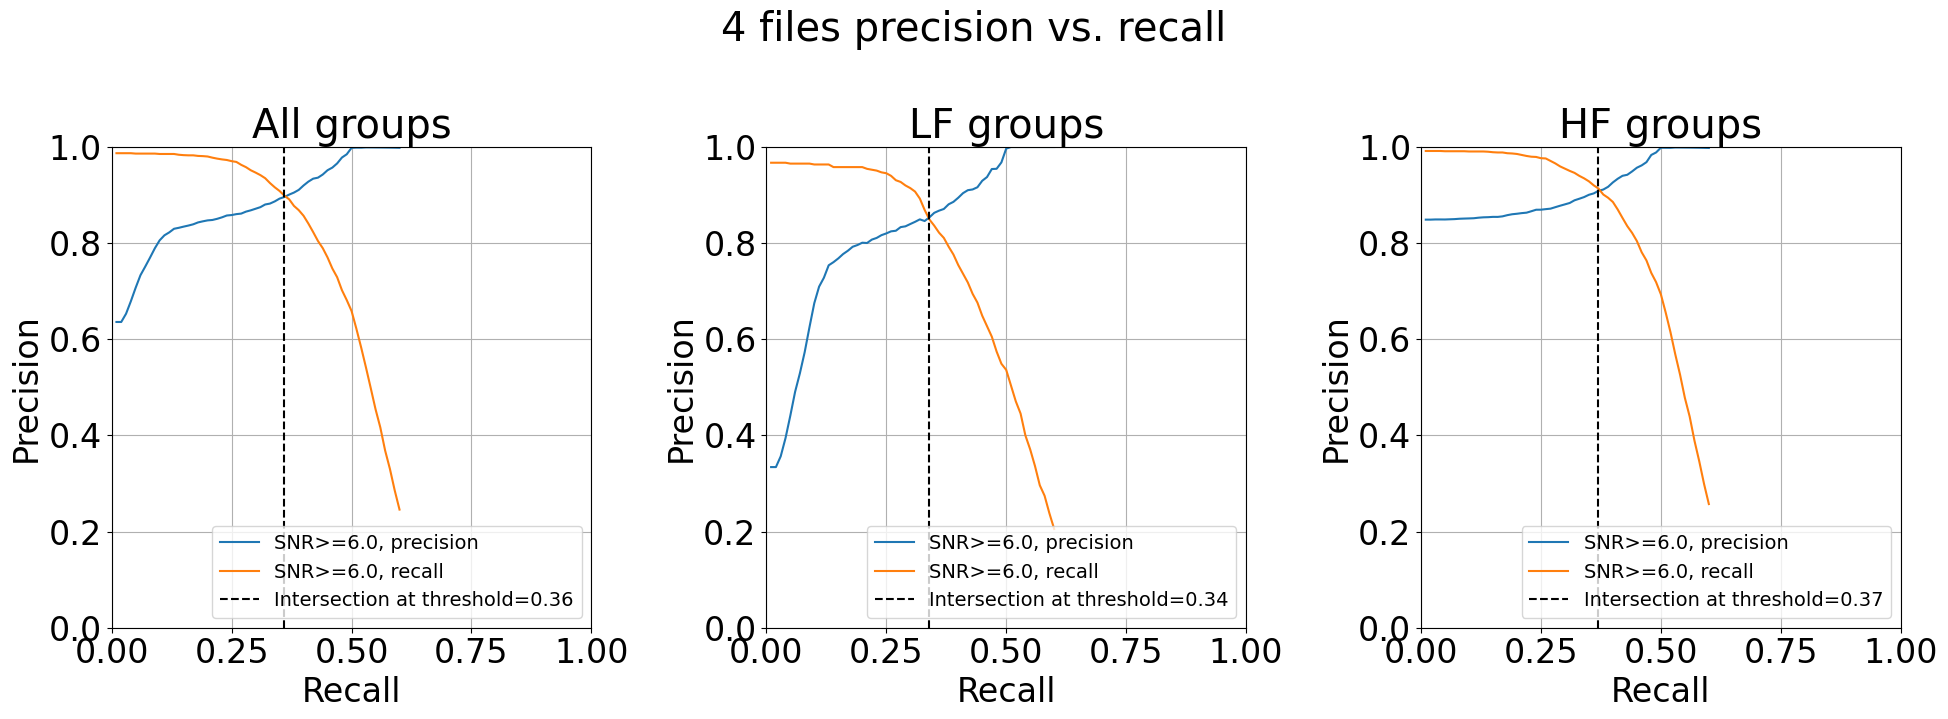

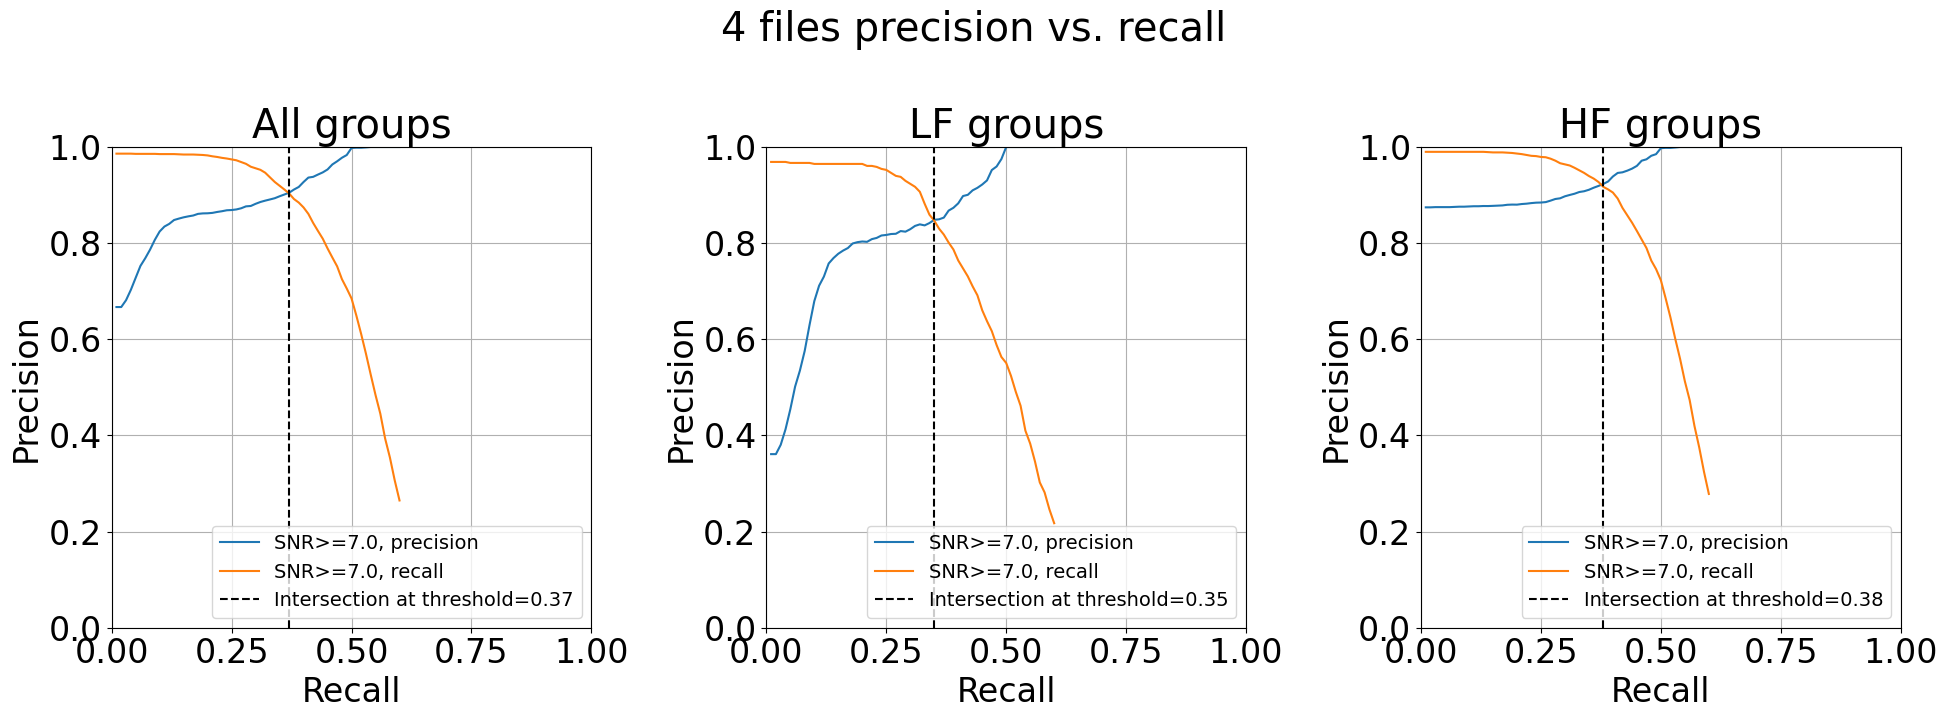

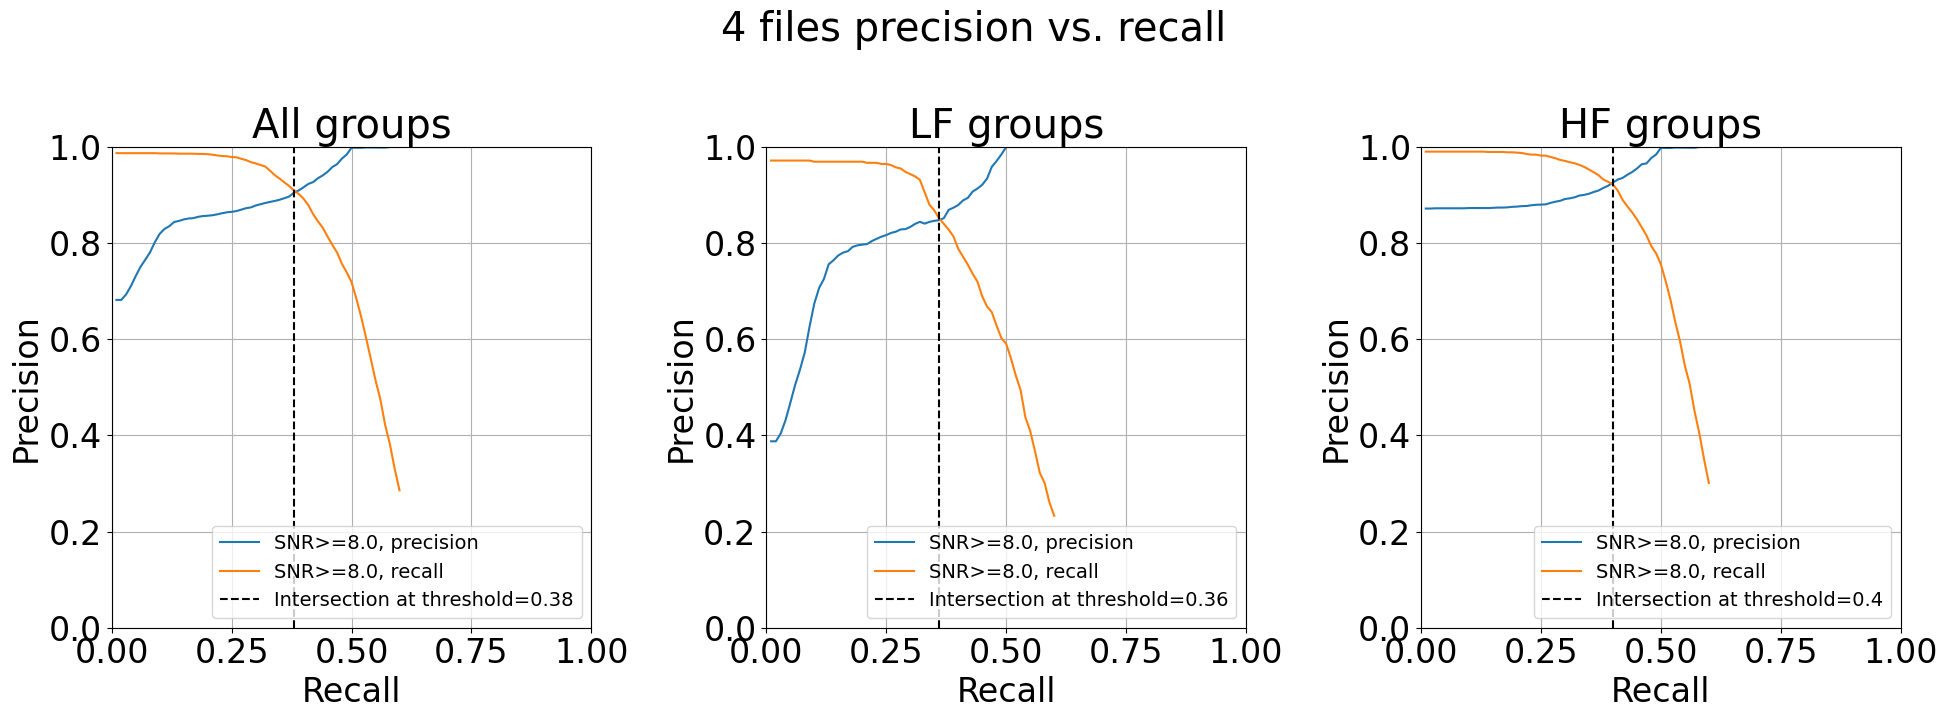

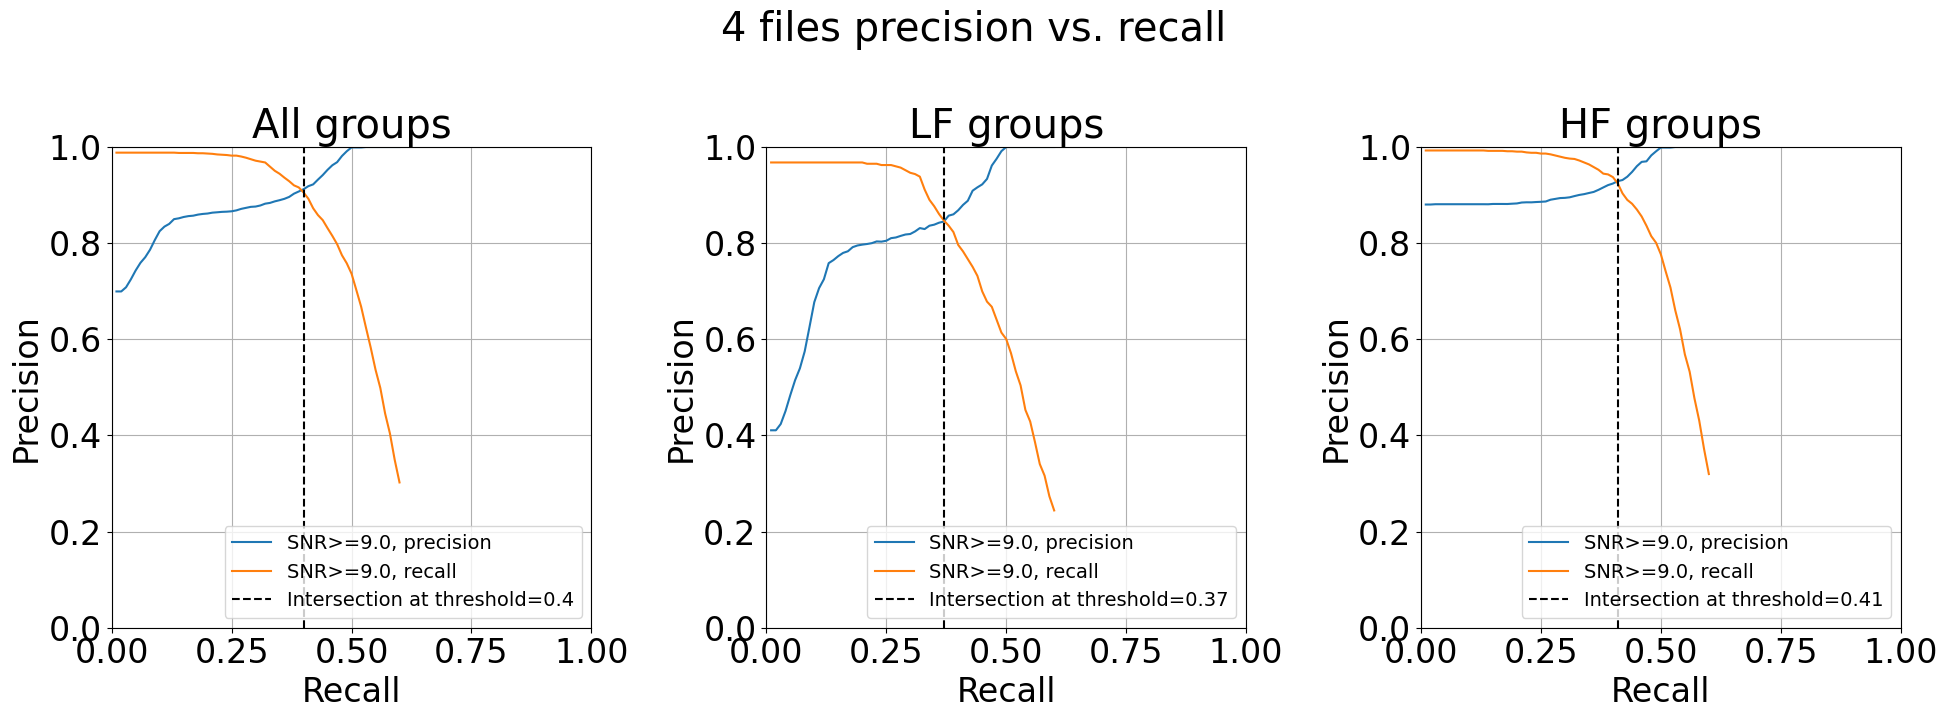

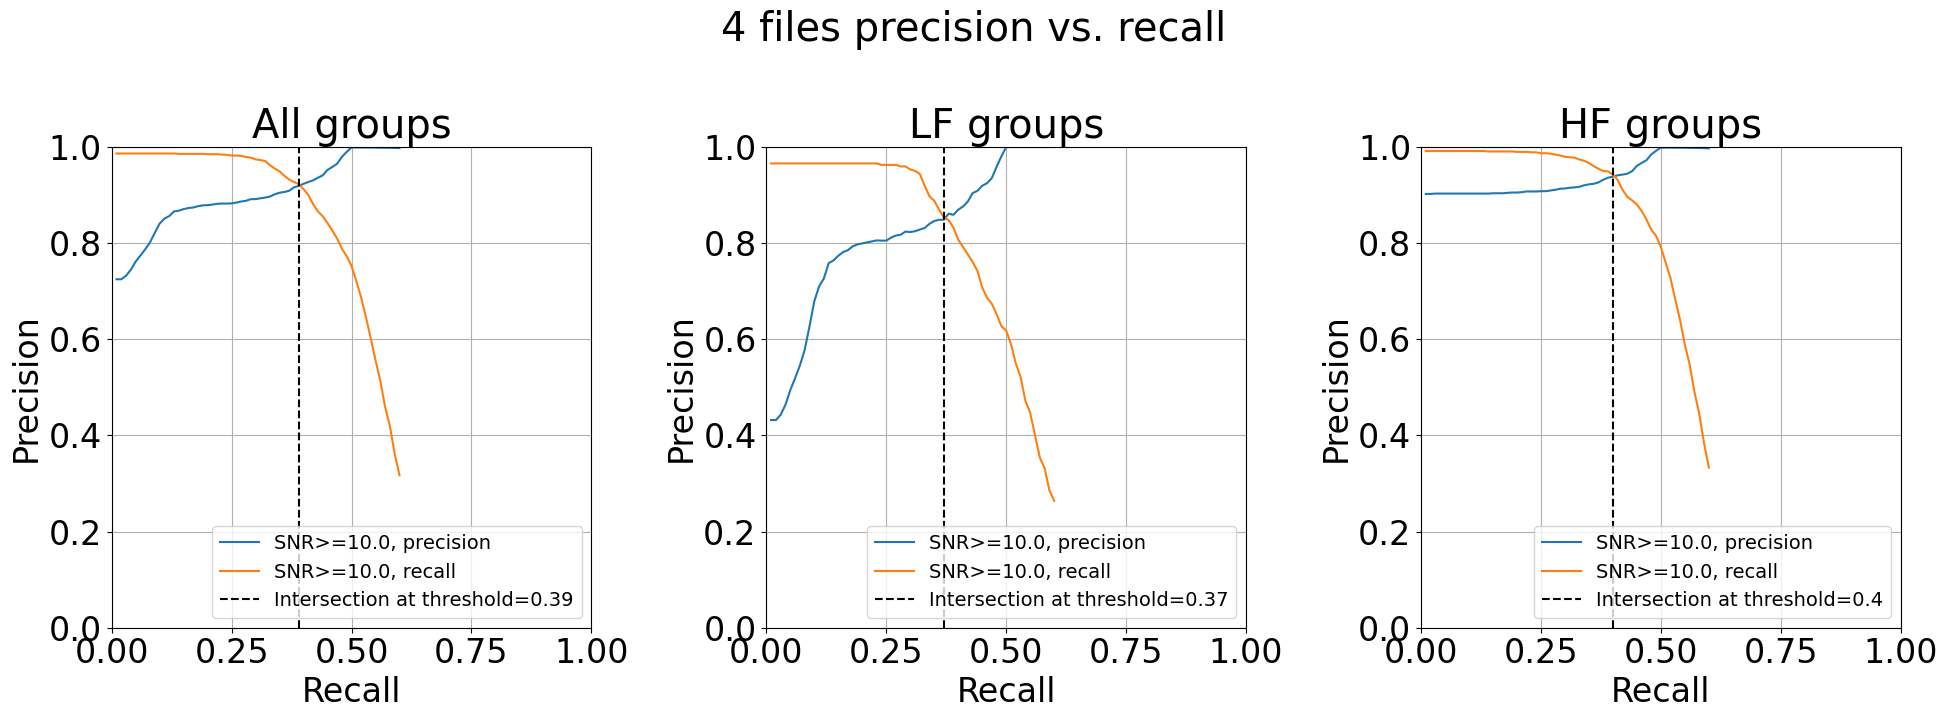

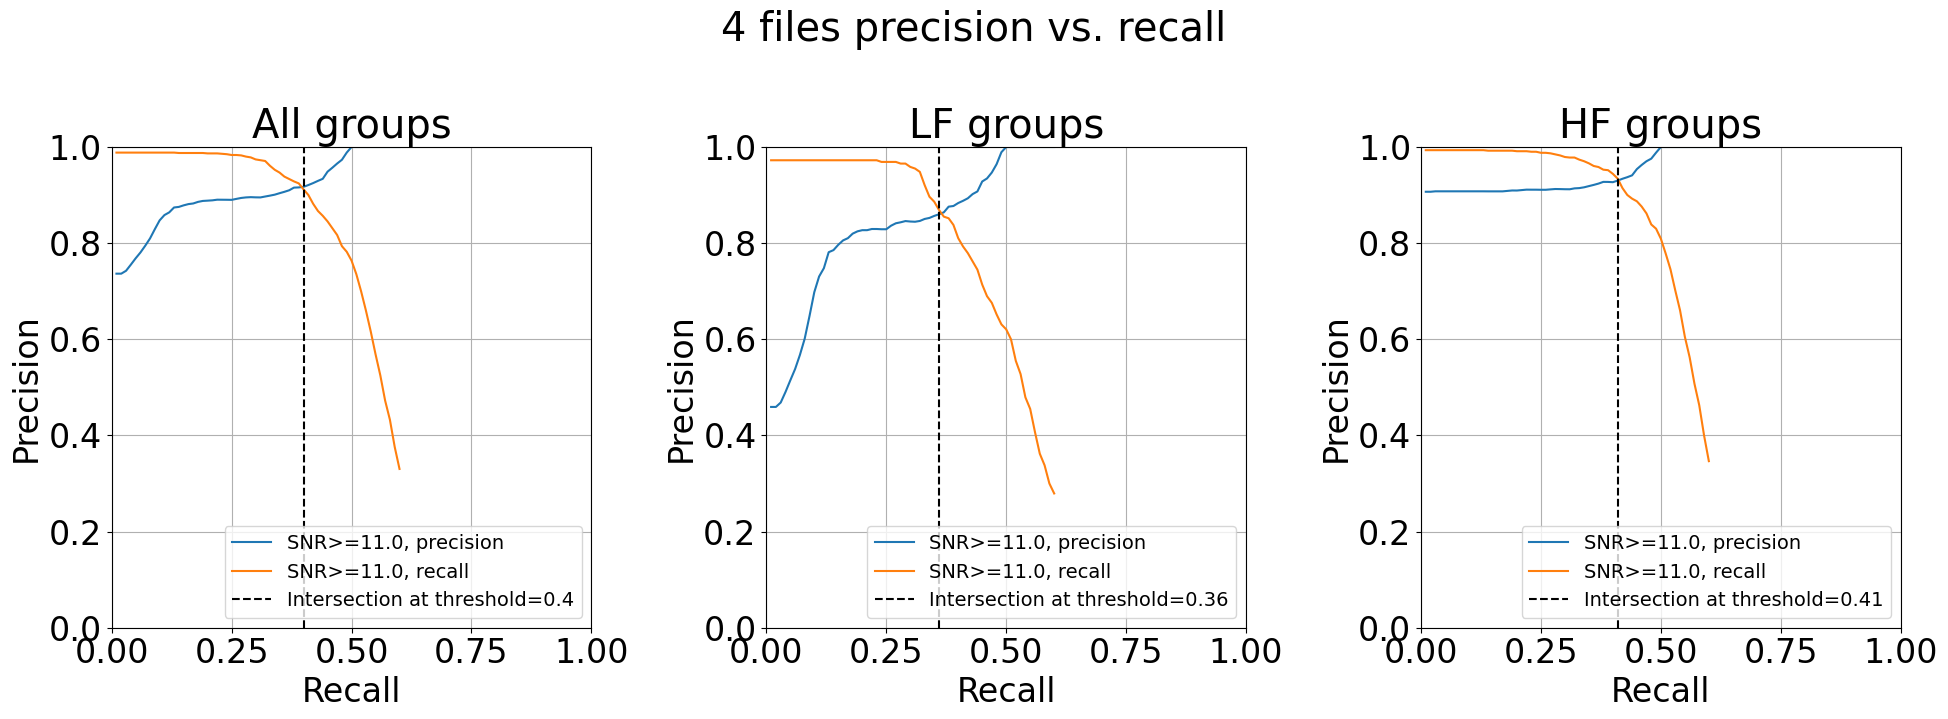

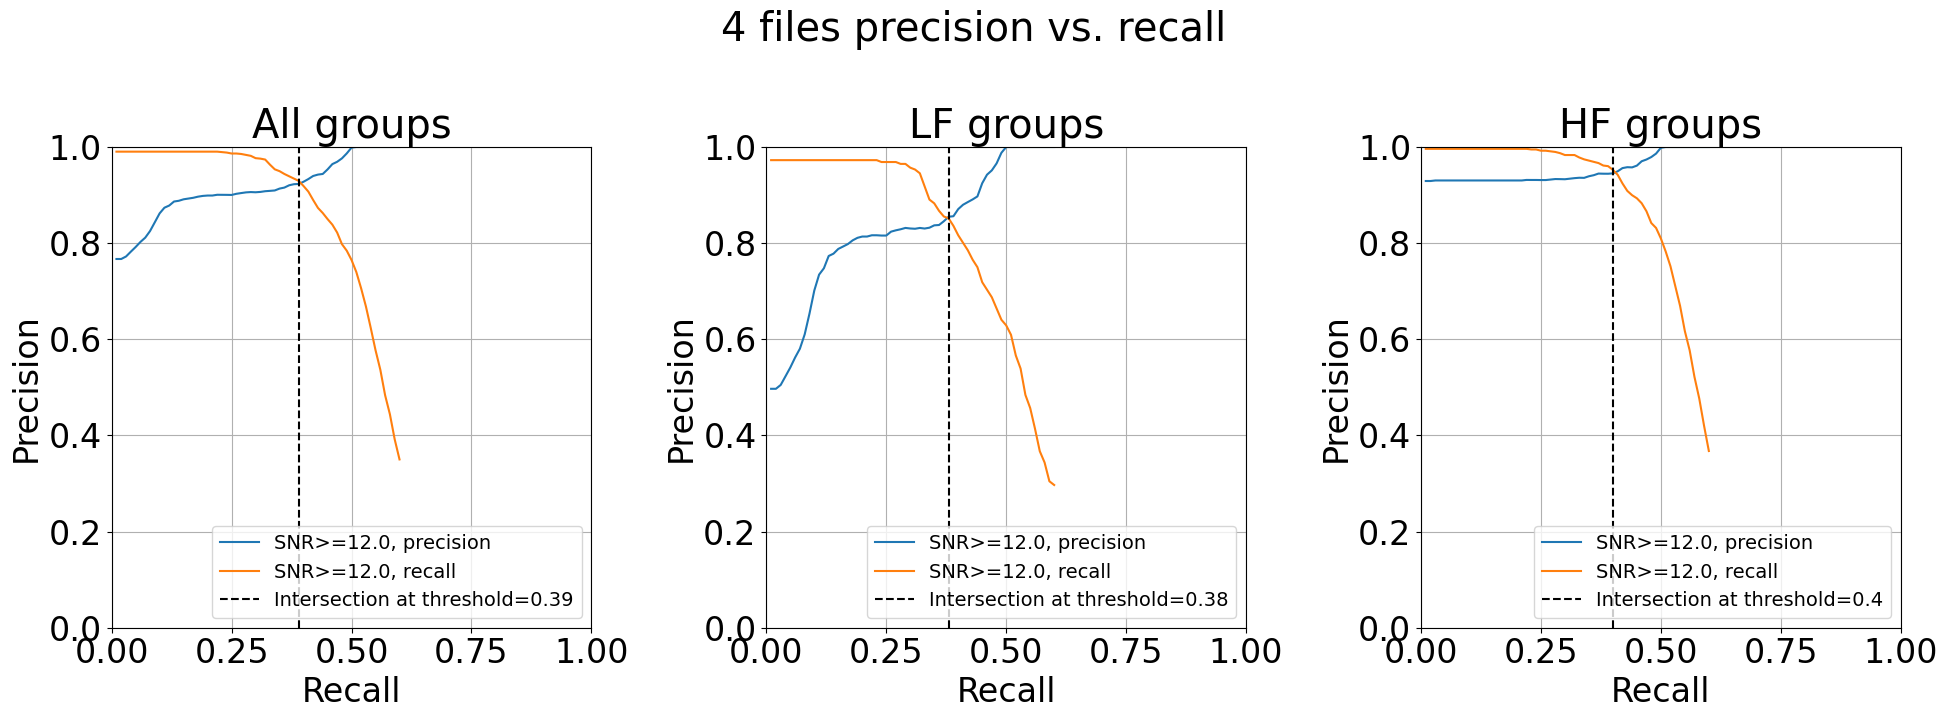

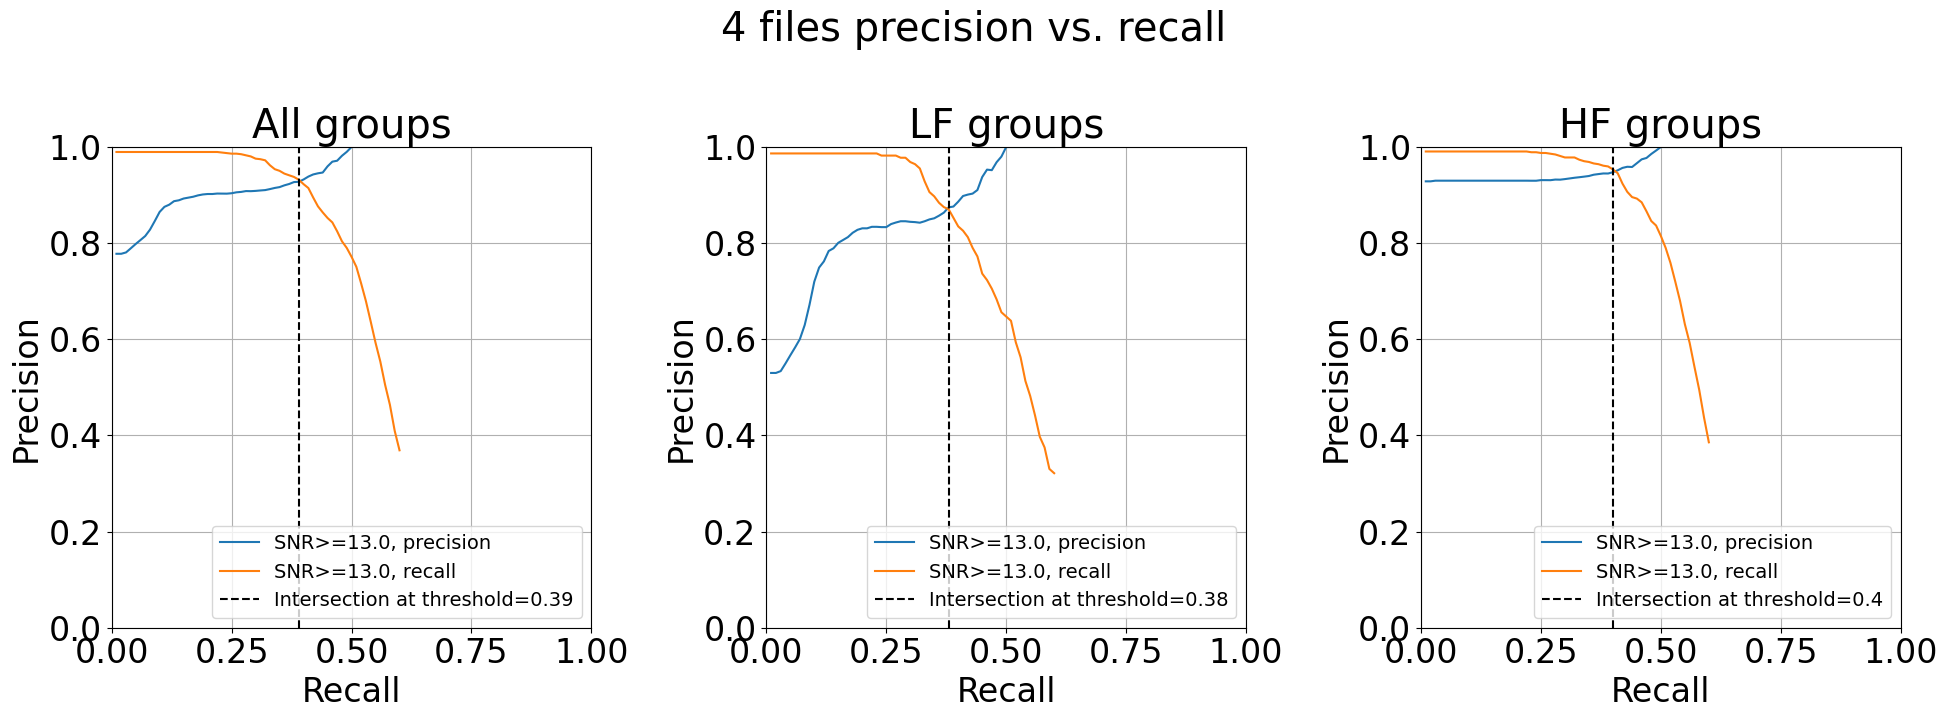

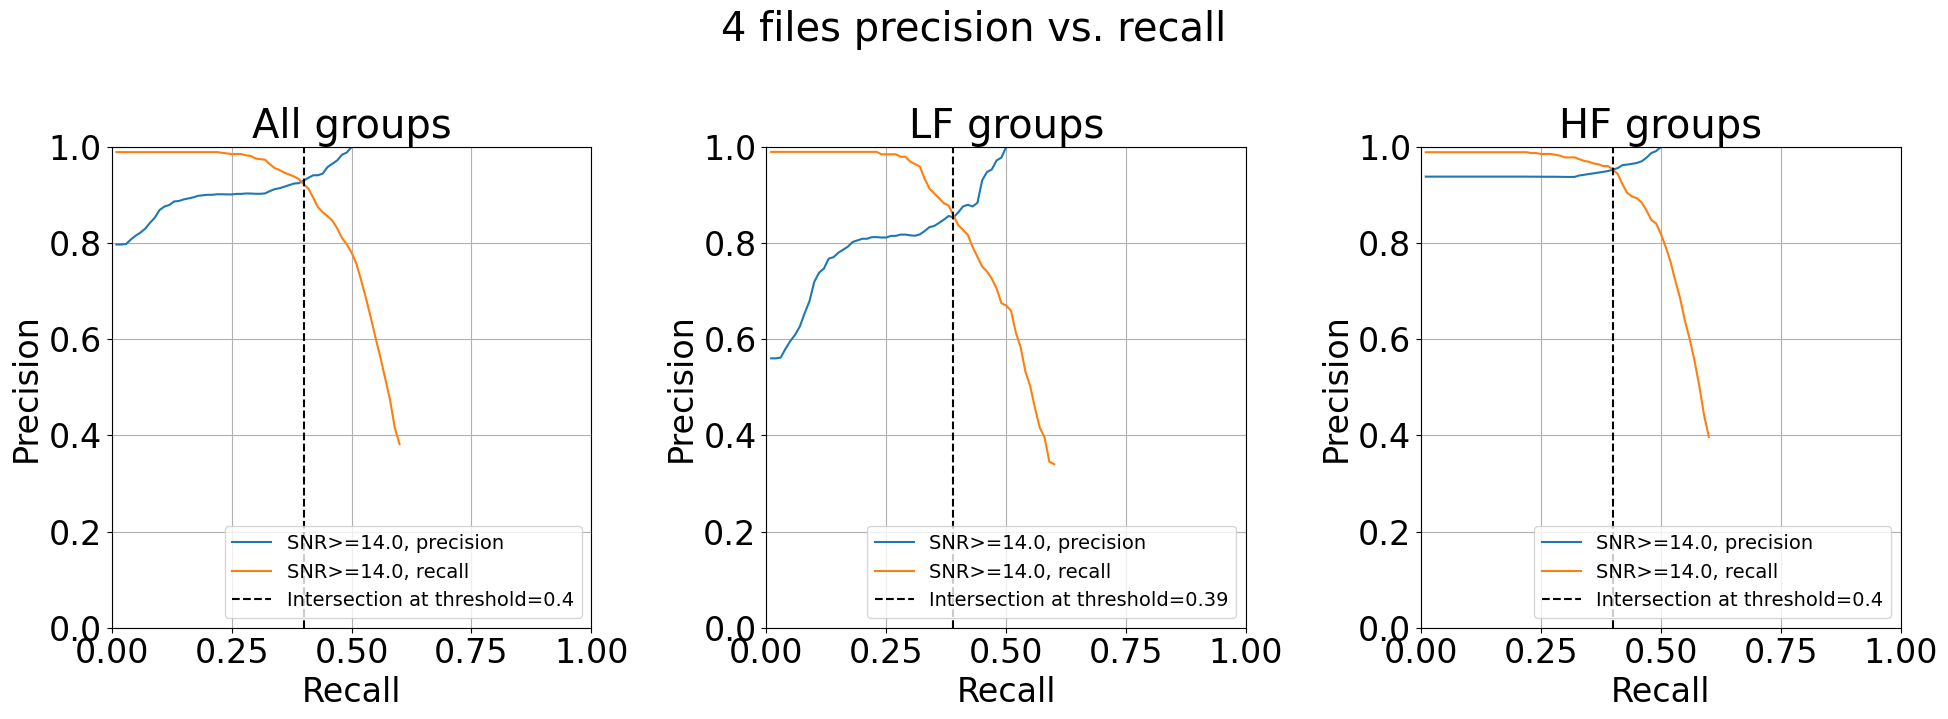

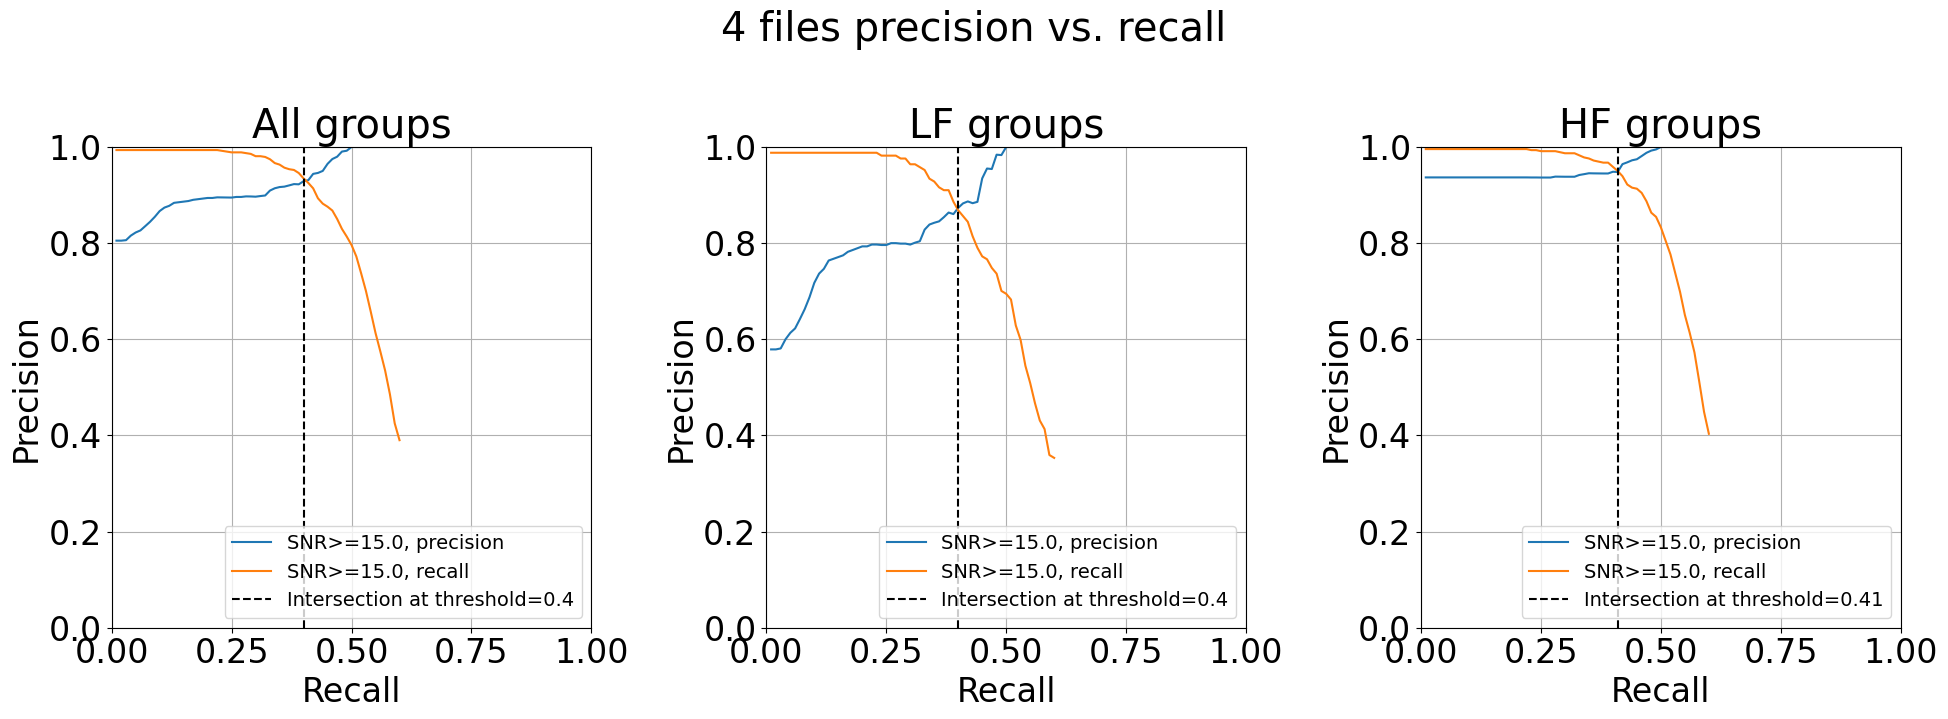

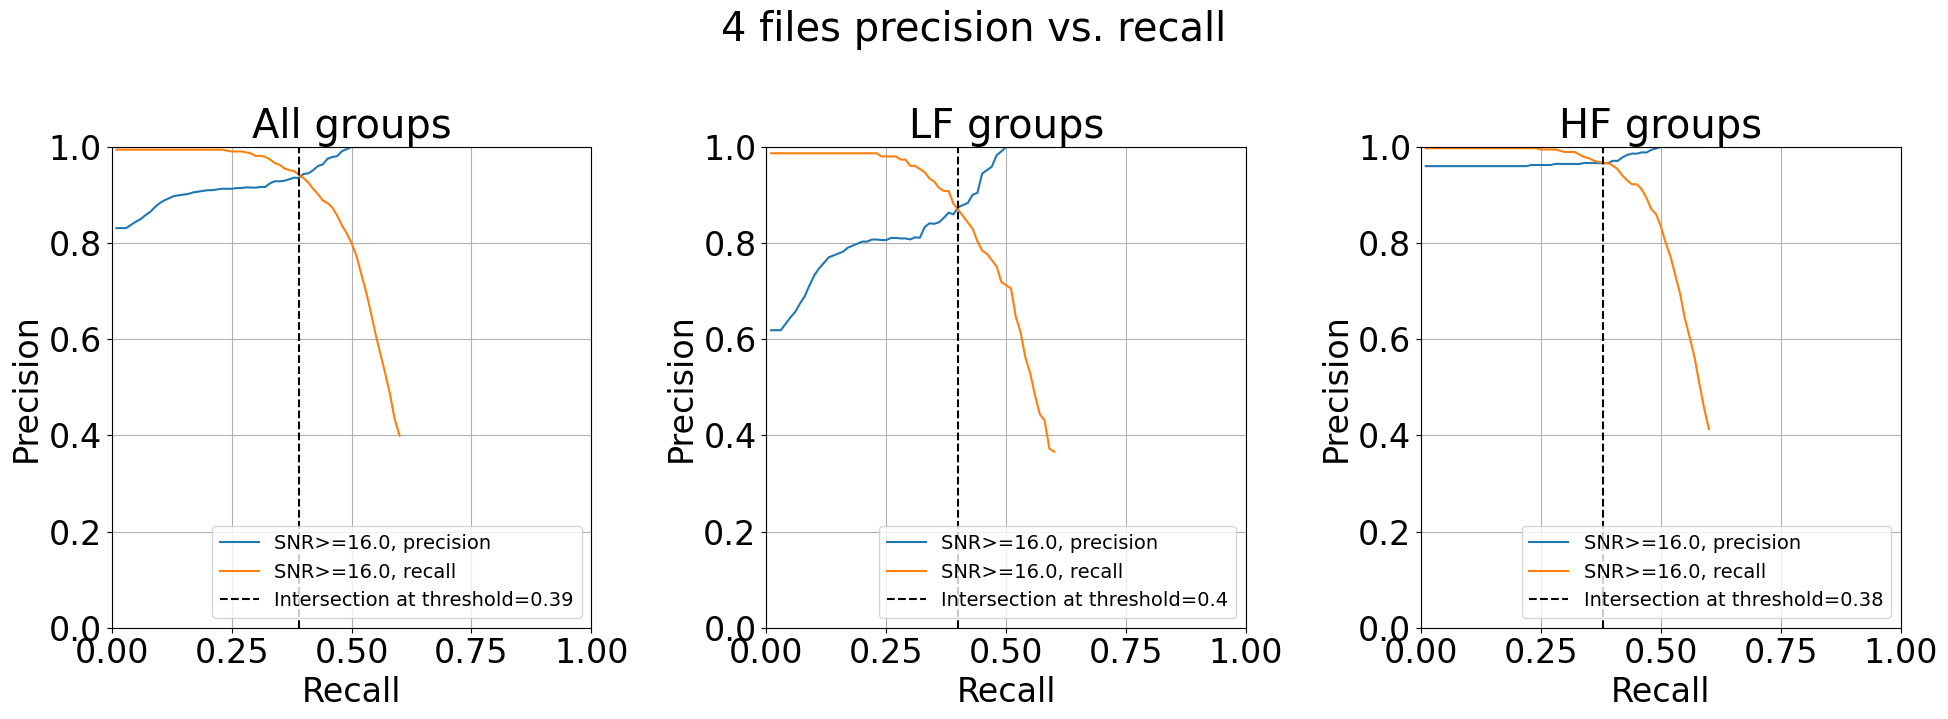

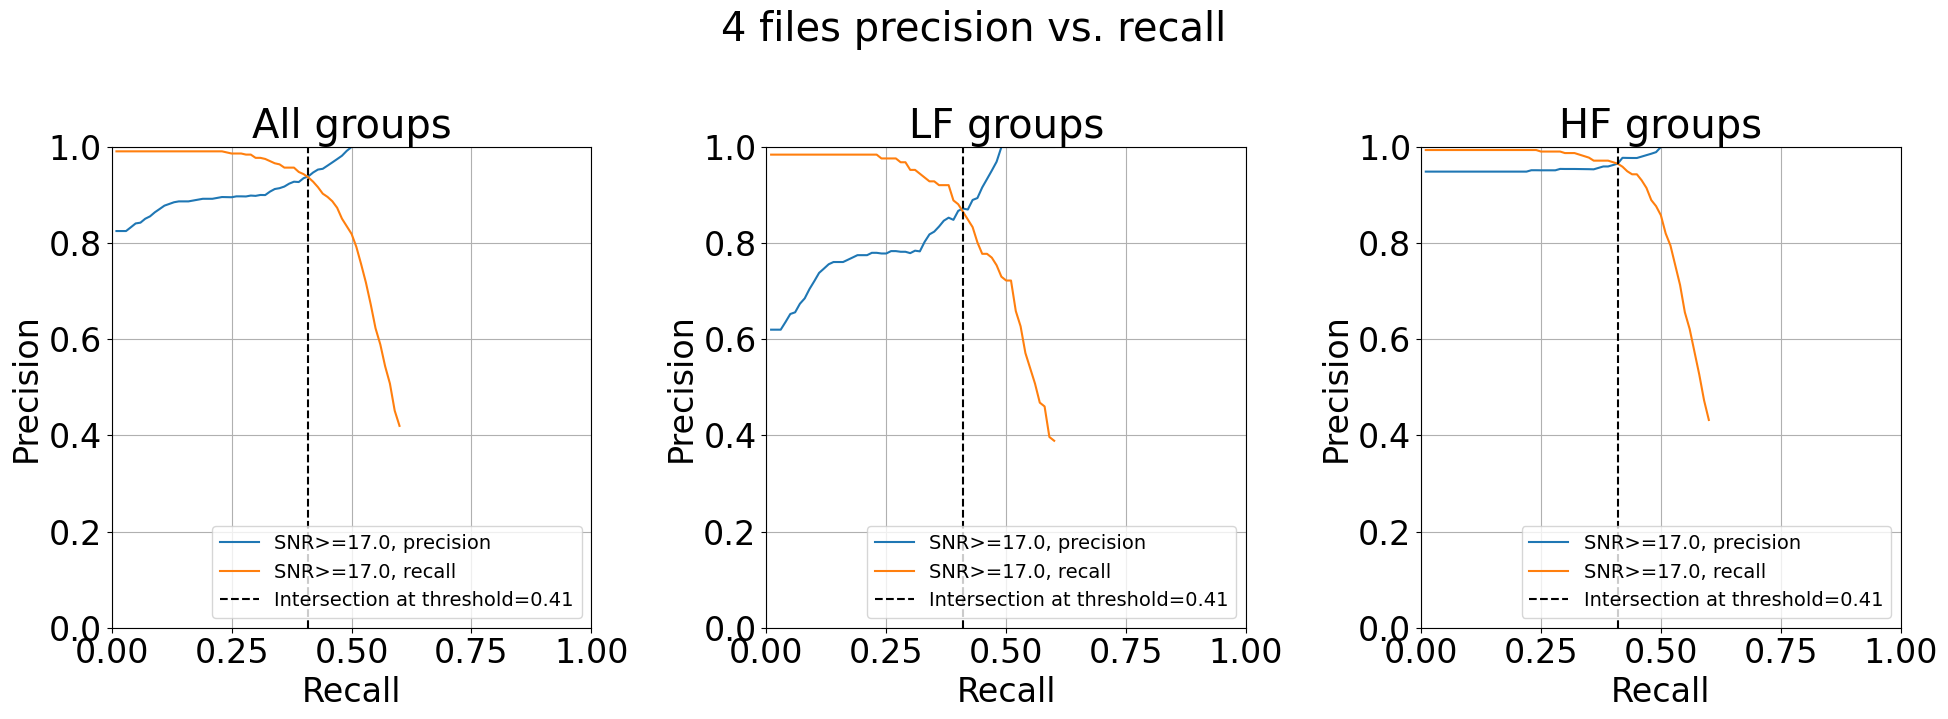

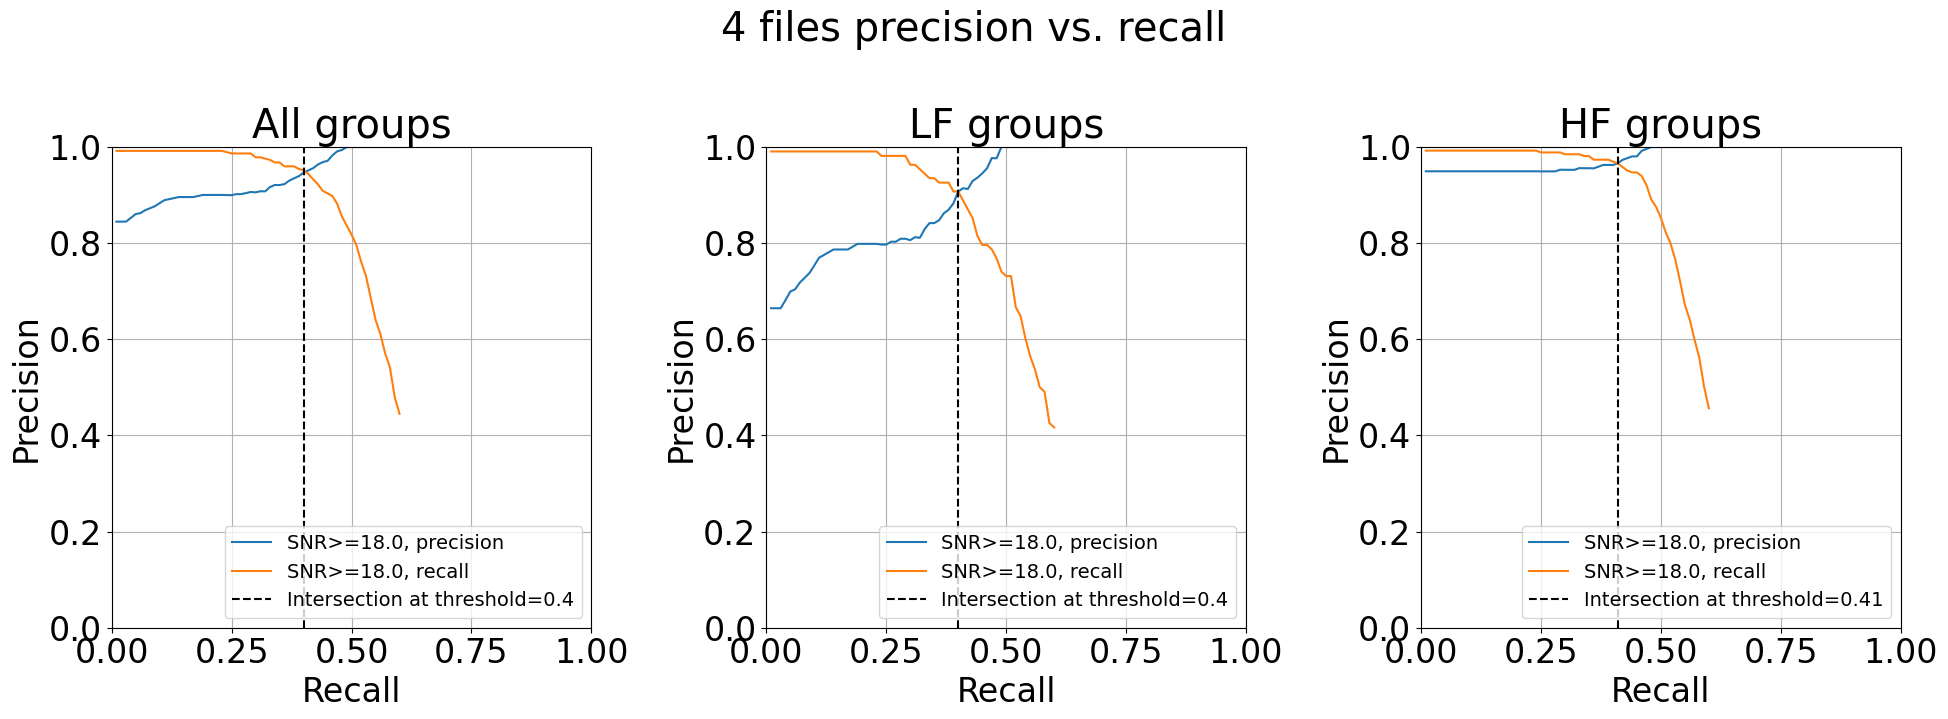

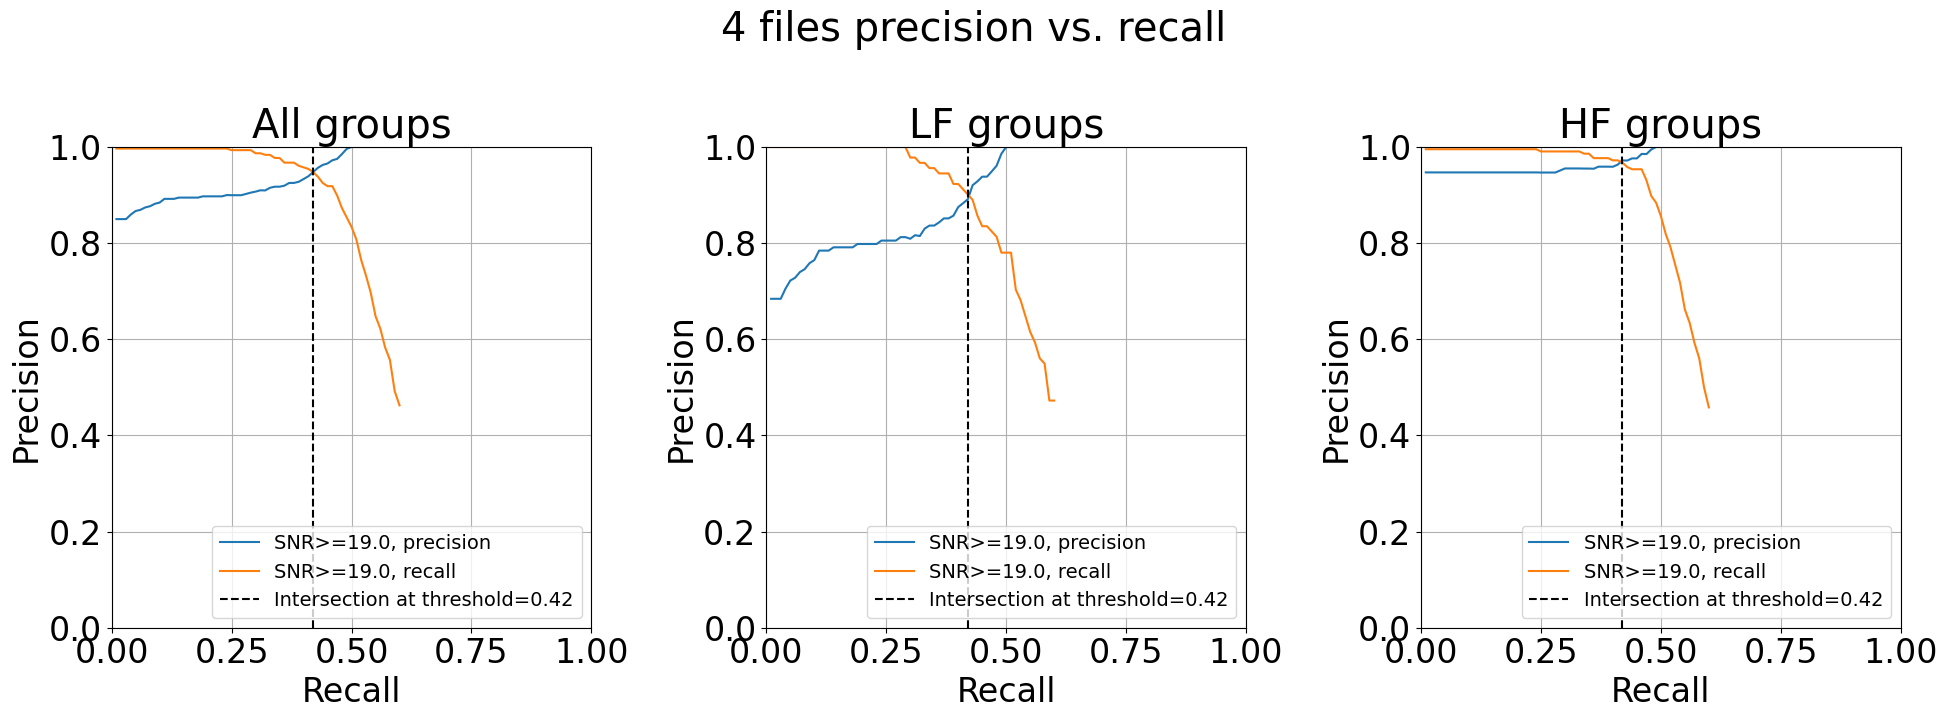

In [ ]:
for SNR_threshold in snr_thresholds:
    fig, ax_all, = plt.subplots(1, 3, figsize=(20,7.5))
    ax_flatten = ax_all.flatten()
    plt.rcParams.update({'font.size':24})
    fig.suptitle(f'4 files precision vs. recall')
    ax = ax_flatten[0]
    ax.set_title(f'All groups')
    all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = precision.index
    optim_thresh = thresholds[np.abs(precision - recall).argmin()]

    ax.plot(precision, label=f'SNR>={round(SNR_threshold, 3)}, precision')
    ax.plot(recall, label=f'SNR>={round(SNR_threshold, 3)}, recall')
    ax.axvline(x=optim_thresh, linestyle='dashed', color='k', label=f'Intersection at threshold={optim_thresh}')
    ax.grid(which='both')
    ax.set_xlim(0.0,1.0)
    ax.set_ylim(0.0,1.0)
    ax.set_xlabel('Detection Threshold')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower right', fontsize=14)

    ax = ax_flatten[1]
    ax.set_title(f'LF groups')
    lf_all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    lf_all_files_metrics_summed_by_det_thresh = lf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    LF_precision, LF_recall = get_precision_and_recall_from_metrics(lf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            lf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(LF_precision - LF_recall).argmin()]
    ax.plot(LF_precision, label=f'SNR>={round(SNR_threshold, 3)}, precision')
    ax.plot(LF_recall, label=f'SNR>={round(SNR_threshold, 3)}, recall')
    ax.axvline(x=optim_thresh, linestyle='dashed', color='k', label=f'Intersection at threshold={optim_thresh}')
    ax.grid(which='both')
    ax.set_xlim(0.0,1.0)
    ax.set_ylim(0.0,1.0)
    ax.set_xlabel('Detection Threshold')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower right', fontsize=14)

    ax = ax_flatten[2]
    ax.set_title(f'HF groups')
    hf_all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    hf_all_files_metrics_summed_by_det_thresh = hf_all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    HF_precision, HF_recall = get_precision_and_recall_from_metrics(hf_all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            hf_all_files_metrics_summed_by_det_thresh['false_negatives'])
    optim_thresh = thresholds[np.abs(HF_precision - HF_recall).argmin()]
    ax.plot(HF_precision, label=f'SNR>={round(SNR_threshold, 3)}, precision')
    ax.plot(HF_recall, label=f'SNR>={round(SNR_threshold, 3)}, recall')
    ax.axvline(x=optim_thresh, linestyle='dashed', color='k', label=f'Intersection at threshold={optim_thresh}')
    ax.grid(which='both')
    ax.set_xlim(0.0,1.0)
    ax.set_ylim(0.0,1.0)
    ax.set_xlabel('Detection Threshold')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower right', fontsize=14)

    fig.tight_layout()
    plt.show()

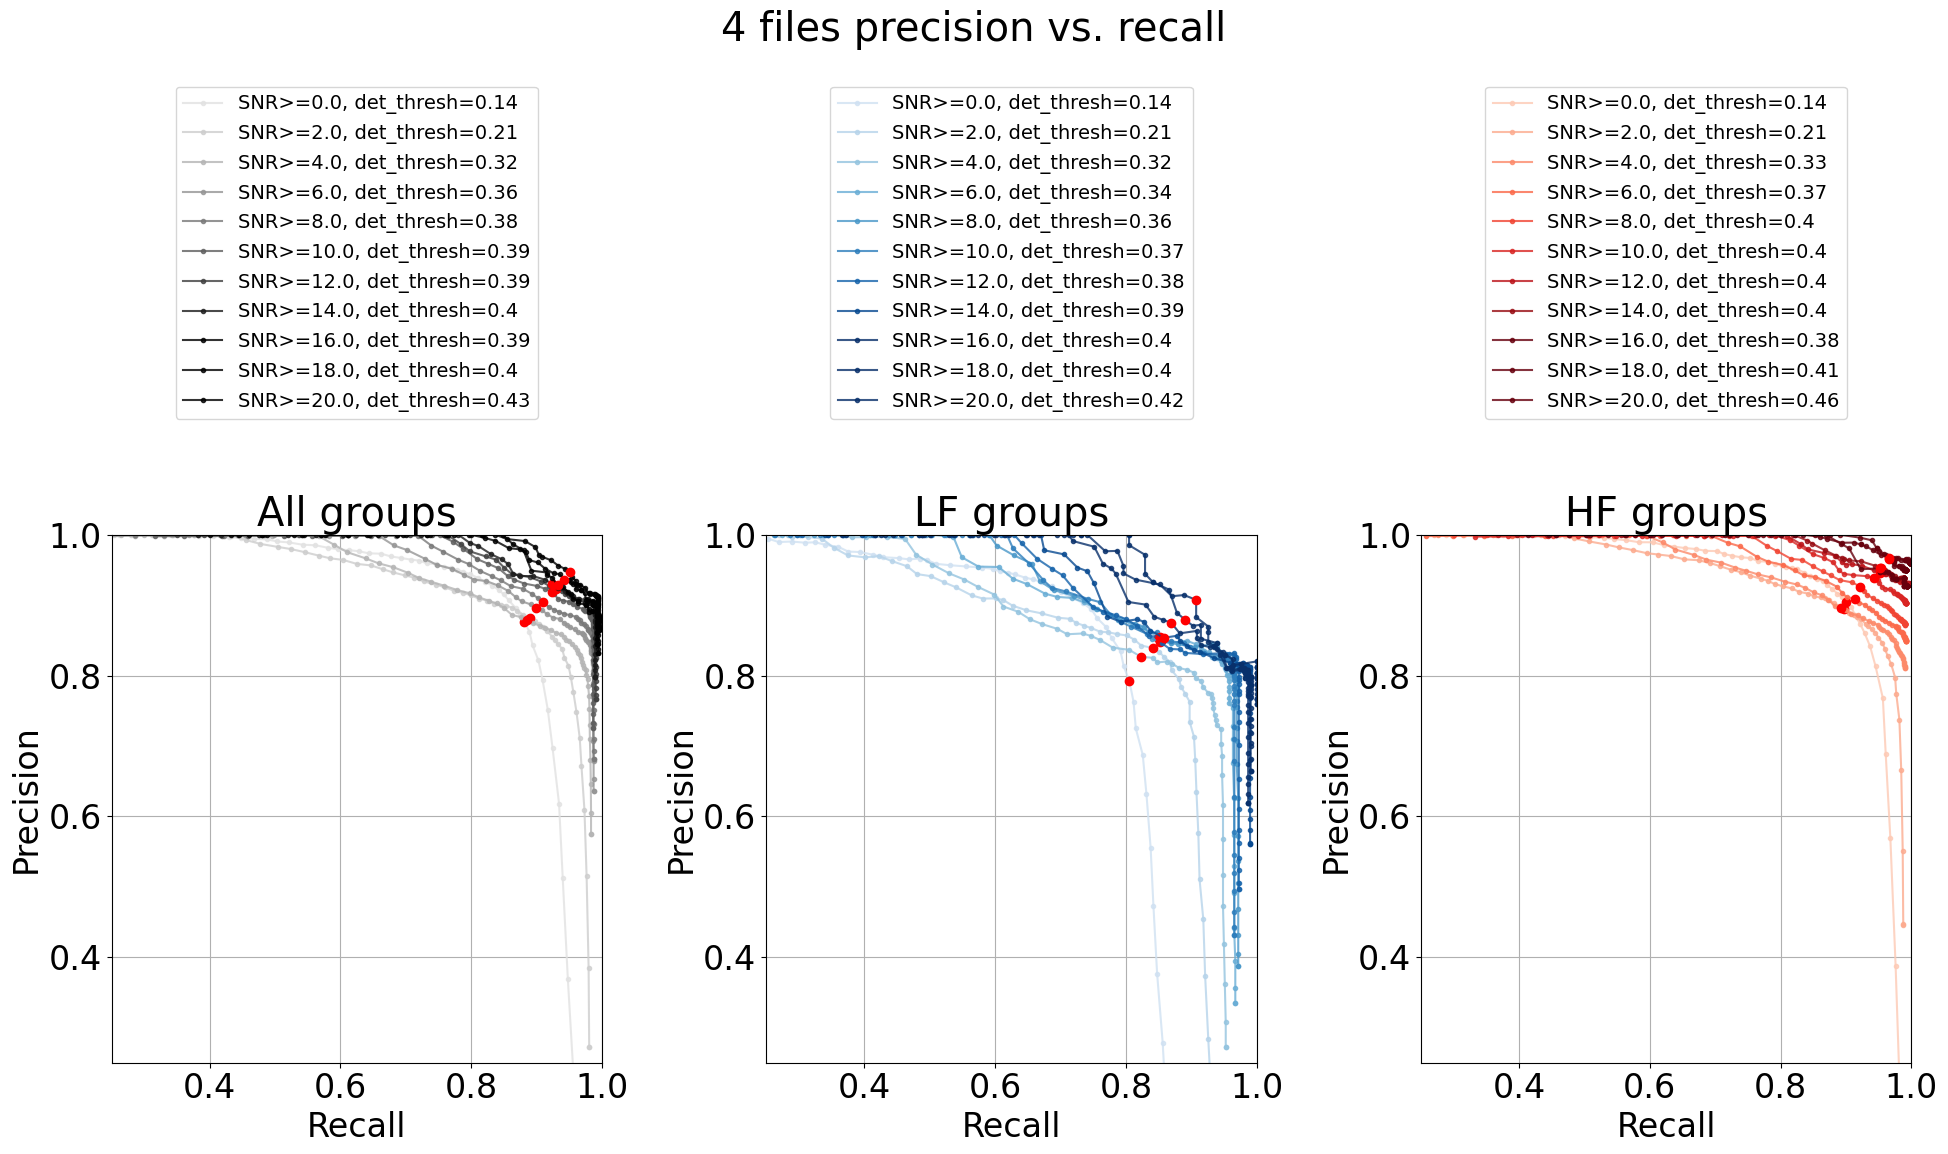

In [18]:
fig, ax_all, = plt.subplots(1, 3, figsize=(20,13))
ax_flatten = ax_all.flatten()

plt.rcParams.update({'font.size':24})
fig.suptitle(f'4 files precision vs. recall', y=0.90)
ax = ax_flatten[0]
ax.set_title(f'All groups')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])

    thresholds = all_files_metrics_summed_by_det_thresh.index
    quality_ind = np.abs(precision - recall).argmin()
    # Get color for current SNR threshold
    line_color = colormap(0.2+norm(SNR_threshold))

    ax.plot(recall, precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[quality_ind], 3)}')
    ax.scatter(recall.iloc[quality_ind], precision.iloc[quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.25,1.0)
ax.set_ylim(0.25,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='lower center', fontsize=14)

ax = ax_flatten[1]
ax.set_title(f'LF groups')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    LF_precision, LF_recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    LF_quality_ind = np.abs(LF_precision - LF_recall).argmin()
    # Get color for current SNR threshold
    line_color = LF_colormap(0.2+norm(SNR_threshold))

    ax.plot(LF_recall, LF_precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[LF_quality_ind], 3)}')
    ax.scatter(LF_recall.iloc[LF_quality_ind], LF_precision.iloc[LF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.25,1.0)
ax.set_ylim(0.25,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='lower center', fontsize=14)

ax = ax_flatten[2]
ax.set_title(f'HF groups')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    HF_precision, HF_recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    HF_quality_ind = np.abs(HF_precision - HF_recall).argmin()
    # Get color for current SNR threshold
    line_color = HF_colormap(0.2+norm(SNR_threshold))

    ax.plot(HF_recall, HF_precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[HF_quality_ind], 3)}')
    ax.scatter(HF_recall.iloc[HF_quality_ind], HF_precision.iloc[HF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.25,1.0)
ax.set_ylim(0.25,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='lower center', fontsize=14)

fig.tight_layout()
plt.show()